## Faster R-CNN(coco_pytorch)

- Faster RCNN : https://pytorch.org/vision/0.9/_modules/torchvision/models/detection/faster_rcnn.html#fasterrcnn_resnet50_fpn

- COCO API : https://github.com/cocodataset/cocoapi


### 데이터 다운로드

MS COCO 데이터셋은 약 328000장의 이미지와 80개의 클래스로 이루어져있으나, 워낙 대규모이기 때문에 개와 고양이 클래스를 소규모로 샘플링해 실습을 진행합니다.



In [ ]:
# '#'이나 '!'으로 시작하는 이 줄은 특별한 명령어입니다. 파이썬 코드가 아니라, 코드를 실행하는 환경(예: Google Colab, Jupyter Notebook)에 직접 내리는 지시입니다.
# 'pip'는 파이썬의 패키지 관리자로, 다른 사람들이 만들어 놓은 유용한 코드 묶음(라이브러리 또는 패키지)을 설치, 업그레이드, 삭제할 때 사용합니다.
# 'install kaggle'은 'kaggle'이라는 이름의 패키지를 설치하라는 의미입니다. 'kaggle' 패키지는 데이터 과학 경진대회 플랫폼인 캐글(Kaggle)의 데이터셋이나 모델을 코드에서 쉽게 다운로드하고 사용할 수 있게 도와주는 도구입니다.
# '--upgrade' 옵션은 만약 'kaggle' 패키지가 이미 설치되어 있다면 최신 버전으로 업데이트하라는 뜻입니다. 최신 기능을 사용하거나 기존의 오류를 해결하기 위해 항상 최신 버전을 유지하는 것이 좋습니다.
# 기계적 구동 과정:
# 1. 사용자가 이 셀을 실행하면, 실행 환경(Colab 등)은 이 줄이 파이썬 코드가 아님을 인지합니다.
# 2. 운영 체제의 터미널(명령 프롬프트)을 열어 'pip install kaggle --upgrade' 명령을 대신 입력해 줍니다.
# 3. 'pip' 프로그램이 실행되어 인터넷을 통해 파이썬 패키지 저장소(PyPI)에 접속합니다.
# 4. 저장소에서 'kaggle' 패키지를 검색하고, 최신 버전을 찾아 다운로드합니다.
# 5. 다운로드한 파일을 현재 파이썬 환경에 설치하거나, 이미 설치된 구버전이 있다면 새 버전으로 덮어씁니다.

!pip install kaggle --upgrade

In [ ]:
import kagglehub
# 'import'는 파이썬에서 다른 코드 파일(모듈 또는 라이브러리)에 있는 기능들을 가져와서 사용하고 싶을 때 쓰는 명령어입니다.
# 'kagglehub'는 위에서 설치한 'kaggle' 라이브러리의 일부로, 캐글에 있는 데이터셋, 모델 등을 쉽게 다운로드할 수 있는 기능들을 모아놓은 모듈입니다.
# 이 코드를 실행하는 이유는, 바로 아래 줄에서 'kagglehub' 모듈 안에 있는 'dataset_download'라는 함수를 사용하기 위함입니다. 'import'를 하지 않으면 파이썬은 'kagglehub'가 무엇인지 알 수 없어 오류를 발생시킵니다.
# 기계적 구동 과정:
# 1. 파이썬 인터프리터(코드를 한 줄씩 읽고 실행하는 프로그램)가 'import kagglehub'를 만납니다.
# 2. 파이썬이 설치된 여러 폴더들을 뒤져서 'kagglehub'라는 이름의 모듈(코드 파일)을 찾습니다. (위에서 pip로 설치했기 때문에 찾을 수 있습니다.)
# 3. 해당 모듈의 코드를 메모리로 불러옵니다.
# 4. 이제부터 이 코드 파일 안에서는 'kagglehub'라는 이름으로 해당 모듈의 모든 기능(함수, 변수 등)에 접근할 수 있게 됩니다.

import os
# 'os'는 'Operating System'의 약자로, 파이썬이 현재 실행되고 있는 컴퓨터의 운영체제(Windows, macOS, Linux 등)와 상호작용할 수 있게 해주는 기본 내장 모듈입니다.
# 'os' 모듈을 사용하면 파일이나 폴더(디렉토리)를 만들거나, 삭제하거나, 경로를 확인하는 등 파일 시스템과 관련된 여러 작업을 할 수 있습니다.
# 이 코드에서는 나중에 다운로드한 파일의 위치를 옮기거나, 작업 폴더를 변경하는 등의 작업을 하기 위해 미리 'import' 해두는 것입니다.
# 기계적 구동 과정:
# 1. 파이썬 인터프리터가 'import os'를 만납니다.
# 2. 'os'는 파이썬 설치 시 기본적으로 포함된 표준 라이브러리이므로, 시스템에서 즉시 'os' 모듈을 찾을 수 있습니다.
# 3. 해당 모듈의 코드를 메모리로 불러옵니다.
# 4. 이제부터 'os'라는 이름으로 운영체제 관련 기능들을 사용할 수 있게 됩니다.

# Download latest version
path = kagglehub.dataset_download("s076923/pytorch-transformer")
# 이 줄은 실제로 캐글에서 데이터셋을 다운로드하는 핵심적인 부분입니다.
# 'kagglehub.dataset_download(...)'는 'kagglehub' 모듈 안에 있는 'dataset_download'라는 함수를 호출(실행)하는 코드입니다.
# '()' 안에 들어가는 "s076923/pytorch-transformer"는 함수의 입력값(인자)으로, 다운로드하고 싶은 데이터셋의 고유 주소입니다. 캐글에서는 '사용자이름/데이터셋이름' 형식으로 데이터를 관리합니다.
# 이 함수가 실행되면, 캐글 서버에 접속하여 해당 데이터셋을 찾고, 내 컴퓨터(또는 Colab 환경)의 특정 임시 폴더로 파일을 다운로드합니다. 보통 압축 파일(.zip) 형태로 받아집니다.
# '=' 기호는 대입 연산자로, 오른쪽에서 실행된 결과값을 왼쪽의 변수에 저장하라는 의미입니다.
# 즉, 'dataset_download' 함수가 다운로드를 완료하면, 파일이 저장된 경로(예: '/tmp/kagglehub/datasets/s076923/pytorch-transformer/1')를 알려주는데, 이 경로 정보(문자열)를 'path'라는 이름의 변수에 저장합니다.
# 이제 'path' 변수를 통해 다운로드된 파일에 접근할 수 있습니다.
# 기계적 구동 과정:
# 1. 'kagglehub.dataset_download' 함수가 "s076923/pytorch-transformer"라는 인자와 함께 호출됩니다.
# 2. 함수 내부적으로 캐글 서버 API에 "s076923/pytorch-transformer" 데이터셋을 요청합니다.
# 3. 인증 과정(보통 Kaggle API 토큰 필요)을 거친 후, 서버는 데이터 파일을 전송해 줍니다.
# 4. 함수는 받은 데이터를 컴퓨터의 정해진 임시 저장 공간에 파일(아마도 .zip 파일)로 저장합니다.
# 5. 저장이 완료된 파일의 전체 경로(문자열)를 결과값으로 반환(return)합니다.
# 6. 반환된 경로 문자열이 'path'라는 변수에 할당(저장)됩니다.

print("Path to dataset files:", path)
# 'print()' 함수는 파이썬의 가장 기본적인 출력 함수로, 괄호 안의 내용을 화면(콘솔)에 보여줍니다.
# 이 코드를 실행하는 이유는 다운로드가 잘 되었는지, 그리고 파일이 정확히 어느 경로에 저장되었는지를 사용자가 눈으로 직접 확인하게 하기 위함입니다.
# '"Path to dataset files:"'는 화면에 그대로 출력될 문자열이고, 콤마(,) 뒤의 'path'는 변수입니다. 'print' 함수는 이 둘을 한 줄에 이어서 출력해 줍니다.
# 예를 들어, 'path' 변수에 '/root/.kaggle/datasets/...'라는 값이 저장되어 있다면, 화면에는 "Path to dataset files: /root/.kaggle/datasets/..." 와 같이 표시됩니다.
# 기계적 구동 과정:
# 1. 'print' 함수가 호출됩니다.
# 2. 첫 번째 인자인 "Path to dataset files:" 문자열을 가져옵니다.
# 3. 두 번째 인자인 'path' 변수에 저장된 값(캐글 데이터셋이 다운로드된 경로 문자열)을 가져옵니다.
# 4. 이 두 내용을 조합하여 "Path to dataset files: [path 변수의 값]" 형태의 최종 문자열을 만듭니다.
# 5. 이 최종 문자열을 표준 출력(보통은 사용자의 화면)으로 보냅니다.

100%|██████████| 916M/916M [00:06<00:00, 152MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/s076923/pytorch-transformer/versions/4


In [ ]:
# 먼저, 압축 파일(pytorch-transformer.zip)을 지정된 경로(현재 디렉토리)로 압축 해제합니다.
import shutil
# 'shutil'은 'Shell Utilities'의 약자로, 파일이나 폴더를 복사, 이동, 삭제하는 등 파일 관리에 대한 고수준의 기능들을 제공하는 파이썬 표준 라이브러리입니다.
# 위에서 'os' 모듈도 파일 시스템 관련 작업을 하지만, 'shutil'은 'os'보다 더 편리하고 강력한 기능(예: 폴더 전체 복사, 파일 이동)을 제공합니다.
# 여기서는 아래 줄의 'shutil.move()' 함수를 사용하기 위해 'import' 합니다.
# 기계적 구동 과정:
# 1. 파이썬 인터프리터가 'import shutil'을 만납니다.
# 2. 'shutil' 역시 파이썬 표준 라이브러리이므로, 시스템에서 즉시 모듈을 찾아 메모리로 불러옵니다.
# 3. 이제 'shutil'이라는 이름으로 파일 관리 기능들을 사용할 수 있게 됩니다.

shutil.move(path, './')
# 이 코드는 위에서 다운로드한 데이터셋 파일(또는 폴더)을 현재 작업 폴더로 이동시키는 역할을 합니다.
# 'shutil.move(A, B)' 함수는 A(소스)를 B(목적지)로 이동시킵니다.
# 여기서 A는 'path' 변수, 즉 'kagglehub'가 데이터셋을 다운로드한 원래의 임시 폴더 경로입니다.
# B는 './' 인데, 이는 현재 작업 디렉토리(Current Working Directory)를 의미하는 특수한 경로입니다. 즉, 이 코드가 실행되고 있는 바로 그 폴더를 가리킵니다.
# 왜 이 작업을 할까요? 캐글이 다운로드하는 기본 경로는 시스템 깊숙한 곳에 있어 다루기 불편할 수 있습니다. 그래서 다루기 쉬운 현재 폴더로 파일을 가져와서 작업을 편하게 하려는 목적입니다.
# 기계적 구동 과정:
# 1. 'shutil.move' 함수가 호출됩니다.
# 2. 첫 번째 인자인 'path' 변수에서 소스 파일/폴더의 경로를 가져옵니다. (예: '/tmp/kagglehub/datasets/s076923/pytorch-transformer/1')
# 3. 두 번째 인자인 './'를 통해 목적지 경로, 즉 현재 스크립트가 실행 중인 폴더의 경로를 확인합니다. (예: '/content/')
# 4. 운영체제에 파일 이동 명령을 내립니다. 소스 경로에 있는 파일/폴더를 목적지 경로로 옮깁니다.
# 5. 이동이 완료되면, 원래 소스 경로에는 해당 파일/폴더가 더 이상 존재하지 않게 됩니다.

'./4'

In [ ]:
# 작업 디렉토리를 변경합니다.
import os
# 'os' 모듈을 다시 'import' 하고 있습니다. 파이썬에서는 한 번 'import'한 모듈을 다시 'import'해도 아무런 문제가 발생하지 않고, 추가적인 작업 없이 그냥 넘어갑니다.
# 따라서 이 줄은 사실상 불필요하지만, 코드의 명확성을 위해 (다시 os 관련 기능을 쓴다는 것을 보여주기 위해) 남겨두기도 합니다.

os.chdir("/content/4/datasets/")  # 작업할 데이터셋 폴더로 이동 (실행 환경에 따라 경로가 달라질 수 있음)
# 'os.chdir()' 함수는 'Change Directory'의 약자로, 현재 작업 디렉토리를 괄호 안에 지정된 경로로 변경합니다.
# 'cd'라는 터미널 명령어와 동일한 기능을 합니다.
# 위에서 데이터셋 파일을 './' (현재 폴더)로 옮겼고, 만약 그 파일이 압축 파일이었다면 압축을 풀었을 것입니다. 이 코드는 압축 해제 후 생성된 특정 폴더 안으로 직접 '들어가서' 작업을 하겠다는 의미입니다.
# 예를 들어, 현재 위치가 '/content/'이고, 여기서 '/content/4/datasets/'로 이동하면, 이제부터 './'는 '/content/'가 아니라 '/content/4/datasets/'를 의미하게 됩니다.
# 이렇게 작업 디렉토리를 변경하면, 앞으로 파일 경로를 쓸 때 '/content/4/datasets/data.csv'처럼 전체 경로를 다 쓰지 않고, 그냥 'data.csv'처럼 짧게 쓸 수 있어 편리합니다.
# 주석에 언급된 것처럼, "/content/4/datasets/"라는 경로는 Google Colab과 같은 특정 환경에서 사용되는 경로이며, 개인 컴퓨터에서 실행한다면 이 경로는 실제 데이터셋이 있는 경로로 수정해야 합니다.
# 기계적 구동 과정:
# 1. 'os.chdir' 함수가 "/content/4/datasets/" 라는 문자열 인자와 함께 호출됩니다.
# 2. 함수는 운영체제에 현재 프로세스(이 파이썬 스크립트)의 작업 디렉토리를 해당 경로로 변경해달라고 요청합니다.
# 3. 운영체제는 요청받은 경로가 실제로 존재하는지 확인합니다.
# 4. 경로가 존재하면, 현재 스크립트의 기준 위치를 해당 폴더로 변경합니다. 만약 경로가 존재하지 않으면 오류가 발생하며 프로그램이 중단됩니다.

### 데이터셋

COCO 데이터는 "ID"를 기준으로 파싱을 해야 합니다.

이 말은, 예를 들어 특정 이미지(images)에 어떤 라벨(annotations)이 붙어있는지 알려면, 두 목록에 공통으로 들어있는 id와 image_id를 서로 맞춰봐야 한다는 의미입니다.

- images: 이미지 파일 자체에 대한 물리적인 정보(파일명, 크기 등)를 담은 목록입니다.

- annotations: 이미지 안에 '무엇이' '어디에' 있는지에 대한 정답 정보(라벨)를 담은 목록입니다.

- categories: 라벨의 종류(예: 1번은 사람, 2번은 자동차)를 정의해놓은 목록입니다.

```
{
	"info": {
		"year": 2021,
		"version": "1.0",
		"description": "For object detection",
		"date_created": "2021"
	},
	"images": [
		{
			"date_captured": "2021",
			"file_name": "000000000001.jpg",
			"id": 1,
			"height": 480,
			"width": 640
		},
		{
			"date_captured": "2021",
			"file_name": "000000000002.jpg",
			"id": 2,
			"height": 426,
			"width": 640
		},
		{
			"date_captured": "2021",
			"file_name": "000000000003.jpg",
			"id": 3,
			"height": 428,
			"width": 640
		},
		{
			"date_captured": "2021",
			"file_name": "000000000004.jpg",
			"id": 4,
			"height": 425,
			"width": 640
		},
		{
			"date_captured": "2021",
			"file_name": "000000000005.jpg",
			"id": 5,
			"height": 640,
			"width": 481
		}
	],
	"licenses": [
		{
			"id": 1,
			"name": "GNU General Public License v3.0",
			"url": "https://github.com/zhiqwang/yolov5-rt-stack/blob/master/LICENSE"
		}
	],
	"type": "instances",
	"annotations": [
		{
			"segmentation": [
				[
					1.0799999999999272,
					187.69008000000002,
					612.66976,
					187.69008000000002,
					612.66976,
					473.53008000000005,
					1.0799999999999272,
					473.53008000000005
				]
			],
			"area": 174816.81699840003,
			"iscrowd": 0,
			"image_id": 1,
			"bbox": [
				1.0799999999999272,
				187.69008000000002,
				611.5897600000001,
				285.84000000000003
			],
			"category_id": 19,
			"id": 1
		},
		{
			"segmentation": [
				[
					311.73024,
					4.310159999999996,
					631.0102400000001,
					4.310159999999996,
					631.0102400000001,
					232.99032,
					311.73024,
					232.99032
				]
			],
			"area": 73013.00148480001,
			"iscrowd": 0,
			"image_id": 1,
			"bbox": [
				311.73024,
				4.310159999999996,
				319.28000000000003,
				228.68016
			],
			"category_id": 50,
			"id": 2
		},
        ],
"categories": [
		{
			"id": 1,
			"name": "0",
			"supercategory": "0"
		},
		{
			"id": 2,
			"name": "1",
			"supercategory": "1"
		},
		{
			"id": 3,
			"name": "2",
			"supercategory": "2"
		},
        ]
}
```

In [ ]:
'''
## 1. info: 데이터셋의 명찰 🏷️
이 부분은 데이터셋의 메타데이터(Metadata), 즉 '데이터를 설명하기 위한 데이터'를 담고 있습니다.
컴퓨터(모델)가 학습하는 데 직접 사용되지는 않지만, 이 파일을 열어보는 사람에게
"이 데이터셋이 어떤 것이고, 언제, 왜 만들어졌는지"를 알려주는 자기소개 또는 명찰과 같은 역할을 합니다.
'''
# JSON

# "info": {
#     "year": 2021,
#     "version": "1.0",
#     "description": "For object detection",
#     "date_created": "2021"
# },
'''
"year": 데이터셋이 제작된 연도입니다.
"version": 데이터셋의 버전입니다. 데이터가 추가되거나,
           라벨링 오류가 수정되는 등 변경사항이 생길 때마다 버전을 업데이트하여 변경 이력을 관리할 수 있습니다.
"description": 이 데이터셋의 목적을 간결하게 설명합니다. 여기서는 "객체 탐지를 위한 것"이라고 명확히 알려주고 있습니다.
"date_created": 데이터셋이 생성된 날짜입니다.
'''


'''
## 2. images: 이미지 파일 목록 🖼️
이 부분은 데이터셋에 포함된 모든 이미지 파일들의 목록입니다. 대괄호 [...]는 여러 개의 항목이 담긴 리스트(배열)라는 뜻이며,
그 안에 있는 각각의 중괄호 {...}가 이미지 한 장 한 장에 대한 정보를 담고 있는 객체입니다.
'''
# JSON

# "images": [
#     {
#         "date_captured": "2021",
#         "file_name": "000000000001.jpg",
#         "id": 1,
#         "height": 480,
#         "width": 640
#     },
#     {
#         "file_name": "000000000002.jpg",
#         "id": 2,
#         ...
#     },
#     ...
# ],
'''
"file_name": 실제 이미지 파일의 이름입니다. 코드는 이 파일 이름을 보고 디스크에서 해당 JPG 파일을 찾아 불러옵니다.
"height" & "width": 이미지의 세로 및 가로 픽셀 크기 정보입니다.
                    이 정보는 바운딩 박스(bbox) 좌표를 해석하거나 이미지를 처리할 때 사용될 수 있습니다.
"id": (🔥매우 매우 중요🔥) 각 이미지에 부여된 고유 식별 번호입니다. 사람으로 치면 '주민등록번호'와 같습니다.
                             이 데이터셋 안에서 id: 1은 오직 "000000000001.jpg" 이미지만을 가리킵니다.
                             이 id는 나중에 annotations 부분에서 "어떤 이미지에 있는 객체에 대한 설명인지"를 연결해주는
                             핵심적인 다리 역할을 합니다.
'''



'''
## 3. licenses & type: 기타 정보 📜
이 부분들은 데이터셋의 부가적인 정보입니다.
'''
# JSON

# "licenses": [ ... ],
# "type": "instances",
'''
"licenses": 이 데이터셋 이미지들의 저작권 및 사용 규약에 대한 정보를 담습니다. 연구나 상업적 이용 시 중요한 정보이지만,
            모델 학습 자체에는 사용되지 않습니다.
"type": 이 어노테이션 파일의 유형을 나타냅니다. "instances"는 각 객체의 위치와 종류를 개별적으로(instance-by-instance) 정의했다는 의미로,
        이는 **객체 탐지(Object Detection)**나 **인스턴스 분할(Instance Segmentation)**을 위한 데이터셋임을 알려줍니다.
'''



'''
## 4. annotations: 데이터셋의 심장 (정답지) ❤️
이 부분이 바로 데이터셋의 핵심이자 심장입니다. 이미지 안에 있는 객체 하나하나에 대한 모든 정답 정보가 담겨 있습니다.
images와 마찬가지로 대괄호 [...] 안에 수많은 {...}들이 들어있는데, 여기서 각각의 {...}는 이미지 속 객체 단 하나에 대한 설명입니다.

한 이미지 안에 객체가 3개 있다면, 그 이미지와 연결된 annotation 객체도 3개가 존재하게 됩니다.
'''
# JSON

# "annotations": [
#     {
#         "segmentation": [ ... ],
#         "area": 174816.81,
#         "iscrowd": 0,
#         "image_id": 1,
#         "bbox": [1.07, 187.69, 611.58, 285.84],
#         "category_id": 19,
#         "id": 1
#     },
#     {
#         "image_id": 1,
#         "bbox": [311.73, 4.31, 319.28, 228.68],
#         "category_id": 50,
#         "id": 2
#     },
#     ...
# ],
'''
"image_id": (🔥두 번째 핵심 연결고리🔥) 이 어노테이션 정보가 어떤 이미지에 속해 있는지를 알려주는 번호입니다.
                                         image_id: 1은 위 images 리스트에 있던 id: 1번 이미지,
                                         즉 "000000000001.jpg"에 대한 설명이라는 의미입니다.
                                         이 image_id를 통해 이미지와 정답지가 비로소 연결됩니다.
"bbox": **"Bounding Box"**의 약자로, 객체 탐지의 핵심 정보입니다.
        [x, y, width, height] 형식의 숫자 4개로 이루어진 리스트입니다.
x: 이미지의 가장 왼쪽 위 모서리(0,0)를 기준으로, 바운딩 박스의 왼쪽 위 꼭짓점의 x좌표.
y: 이미지의 가장 왼쪽 위 모서리(0,0)를 기준으로, 바운딩 박스의 왼쪽 위 꼭짓점의 y좌표.
width: 바운딩 박스의 가로 길이.
height: 바운딩 박스의 세로 길이.

즉, 이 4개의 숫자는 **"이미지 속 객체가 어디에, 어떤 크기로 있는지"**를 정확하게 알려줍니다.

"category_id": (🔥세 번째 핵심 연결고리🔥) 이 바운딩 박스로 표시된 객체가 무엇인지를 알려주는 번호입니다.
                                             category_id: 19는 이 객체가 "19번 카테고리"에 속한다는 의미입니다.
                                             하지만 숫자 19만 봐서는 이게 고양이인지 자동차인지 알 수 없죠.
                                             이 번호의 실제 의미는 마지막 categories 부분에서 찾을 수 있습니다.

"id": 이 어노테이션 자체의 고유 번호입니다. images의 id와는 별개입니다.

"segmentation": 객체의 외곽선을 점들의 좌표로 정밀하게 그린 정보입니다.
                픽셀 단위로 객체의 모양을 알아야 하는 'Semantic/Instance Segmentation' 모델을 학습시킬 때 사용됩니다.

"area": segmentation 정보에 의해 계산된 객체의 픽셀 넓이입니다.

"iscrowd": 여러 객체가 겹쳐있어 개별적으로 구분하기 어려운 경우 1로 표시합니다. 0은 단일 객체임을 의미합니다.
'''



'''
## 5. categories: 카테고리 사전 📖
이 부분은 annotations에 등장했던 category_id가 실제로 무엇을 의미하는지 알려주는 '사전' 또는 '번역표' 역할을 합니다.
'''
# JSON

# "categories": [
#     {
#         "id": 1,
#         "name": "0",
#         "supercategory": "0"
#     },
#     ...
#     {
#         "id": 19,
#         "name": "horse",
#         "supercategory": "animal"
#     },
#     ...
#     {
#         "id": 50,
#         "name": "spoon",
#         "supercategory": "kitchen"
#     },
#     ...
# ]
# (예시를 위해 내용을 추가했습니다)
'''
"id": 카테고리의 고유 번호입니다. 이 번호가 annotations의 "category_id"와 일치합니다.

"name": 사람이 읽을 수 있는 카테고리의 실제 이름입니다. 예를 들어, id: 19는 name: "horse" (말) 이고, id: 50은 name: "spoon" (숟가락) 입니다.

"supercategory": 더 큰 상위 카테고리를 의미합니다. '말', '고양이', '개'는 모두 'animal'이라는 상위 카테고리에 속할 수 있습니다.
'''



'''
### 총정리: 모든 조각들이 맞춰지는 과정 (The Big Picture) 🧩

이제 이 모든 정보가 어떻게 하나의 그림으로 합쳐져 모델을 학습시키는지 전체적인 과정을 따라가 보겠습니다.

시작점: 이미지 한 장

학습 코드는 먼저 images 리스트에서 이미지 정보 하나를 가져옵니다. 예를 들어, "file_name": "000000000001.jpg"과 "id": 1을 읽습니다.

그리고 "000000000001.jpg" 파일을 실제로 디스크에서 불러와 메모리에 올립니다.

정답지(Annotation) 찾기

이제 이 이미지에 대한 정답을 찾아야 합니다. 코드는 거대한 annotations 리스트 전체를 훑으면서, "image_id": 1인 항목들을 모두 찾아냅니다.

찾아보니 두 개의 항목이 나왔습니다.

첫 번째 항목: "bbox": [1.07, ...], "category_id": 19

두 번째 항목: "bbox": [311.73, ...], "category_id": 50

정답 해석하기

이제 찾은 정답들의 의미를 해석할 차례입니다.

첫 번째 항목의 "category_id": 19를 들고 categories라는 사전으로 갑니다. 사전을 찾아보니 id: 19는 name: "horse"(말)입니다.

두 번째 항목의 "category_id": 50도 categories 사전을 찾아봅니다. id: 50은 name: "spoon"(숟가락)입니다.

최종 학습 데이터 생성

이제 컴퓨터는 완벽한 한 쌍의 학습 세트를 만들었습니다.

입력 데이터: "000000000001.jpg" 이미지

정답 데이터:

(1) 좌표 [1.07, 187.69, 611.58, 285.84]에는 **말(horse)**이 있다.

(2) 좌표 [311.73, 4.31, 319.28, 228.68]에는 **숟가락(spoon)**이 있다.

모델은 이 한 쌍의 데이터를 보고, 이미지의 특정 영역과 '말'이라는 클래스,
또 다른 영역과 '숟가락'이라는 클래스를 연관 짓는 방법을 배우게 됩니다.
이 과정을 images 리스트에 있는 수천, 수만 장의 모든 이미지에 대해 반복하면서 모델은 점점 더 똑똑해지는 것입니다.

결론적으로, 이 JSON 파일은 이미지 파일(images), 정답 정보(annotations),
그리고 **정답의 의미(categories)**라는 세 가지 핵심 요소를 id라는 연결고리를 통해 유기적으로 엮어놓은,
매우 체계적이고 효율적인 객체 탐지 모델용 종합 설명서라고 할 수 있습니다.
'''

# CustomCOCO

In [ ]:
# 'import'는 파이썬의 기본 기능 외에 추가적인 능력을 사용하고 싶을 때,
# 미리 만들어진 코드 묶음(라이브러리 또는 모듈)을 불러오는 명령어입니다.
# 마치 요리를 할 때 필요한 도구들(칼, 도마, 냄비)을 주방 선반에서 꺼내오는 것과 같습니다.

import os           # os는 'Operating System'(운영체제)의 약자입니다.
                    # 이 모듈을 불러오면 파이썬 코드를 통해 파일 경로를 다루거나, 폴더를 생성하는 등
                    # 컴퓨터의 운영체제와 관련된 기능들을 사용할 수 있습니다.
                    # 예를 들어, 'data/images/cat.jpg'와 같은 파일 경로를 안전하게 합치거나 분리할 때 유용합니다.

import json         # JSON(JavaScript Object Notation)은 데이터를 저장하고 교환하는 데 널리 사용되는 텍스트 형식입니다.
                    # 앞에서 우리가 분석했던 그 복잡한 .json 어노테이션 파일이 바로 이것입니다.
                    # 이 'json' 모듈을 불러오면, .json 파일을 파이썬의 딕셔너리(dictionary)나 리스트(list) 형태로 쉽게 읽어오거나,
                    # 반대로 파이썬 데이터를 .json 파일 형식으로 저장할 수 있습니다.

import torch        # PyTorch는 딥러닝 모델을 만들고 학습시키는 데 사용되는 핵심 라이브러리입니다.
                    # 숫자들을 담는 다차원 배열인 '텐서(Tensor)'를 생성하고 계산하는 강력한 기능을 제공합니다.
                    # 이 코드 조각에서는 직접 사용되지 않았지만, 전체 프로젝트의 최종 목표가 딥러닝 모델을 다루는 것이므로 미리 불러온 것입니다.

from PIL import Image  # PIL(Pillow)은 파이썬에서 이미지를 다루기 위한 라이브러리입니다.
                       # 'from PIL import Image'는 PIL 라이브러리 전체가 아닌, 그 안의 'Image'라는 특정 도구(모듈)만 콕 집어서 가져오겠다는 의미입니다.
                       # 이 'Image' 모듈을 사용하면 'cat.jpg'와 같은 이미지 파일을 열고, 크기를 조절하고, 픽셀 데이터를 읽어오는 등의 작업을 할 수 있습니다.

from torch.utils.data import Dataset # PyTorch 라이브러리 안의 'utils.data'라는 서랍에서 'Dataset'이라는 설계도(클래스)를 꺼내옵니다.
                                     # 딥러닝 모델을 학습시키려면 데이터를 '미니 배치(mini-batch)'라는 작은 묶음 단위로 모델에 공급해야 합니다.
                                     # 'Dataset' 클래스는 원본 데이터를 어떻게 읽고, 어떻게 하나씩 꺼내올지에 대한 규칙을 정의하는 '틀' 역할을 합니다.
                                     # 우리는 나중에 이 'Dataset'의 규칙을 따라서 우리만의 데이터 공급 방식을 만들게 됩니다.

# ----------------------------------------------------------------------------------------------------
# COCO 데이터셋의 JSON 파일을 직접 파싱하기 위한 사용자 정의 클래스
# 'class'는 연관 있는 데이터와 함수(기능)들을 하나로 묶어놓은 '설계도' 또는 '틀'입니다.
# 여기서는 COCO JSON 파일을 다루기 위한 모든 기능들을 'CustomCOCO'라는 이름의 설계도 안에 정리해 놓은 것입니다.
# 이렇게 클래스로 묶어두면, 코드가 훨씬 체계적이고 재사용하기 좋아집니다.
class CustomCOCO:
    # '__init__'는 'initialize'(초기화)의 줄임말로, 이 클래스의 설계도로 객체(실체)를 처음 만들 때 딱 한 번 실행되는 특별한 함수입니다.
    # 생성자(Constructor)라고도 부릅니다. 이 함수의 주된 역할은 객체가 앞으로 사용할 초기 데이터들을 준비하고 설정하는 것입니다.
    # 'self'는 클래스로부터 만들어진 객체 '자기 자신'을 가리키는 약속된 이름입니다.
    # 'annotation_file'은 이 클래스로 객체를 만들 때 사용자가 반드시 전달해줘야 하는 '.json' 파일의 경로입니다.
    def __init__(self, annotation_file):
        """
        CustomCOCO 클래스 초기화 함수.
        :param annotation_file: COCO 데이터셋의 어노테이션(JSON) 파일 경로
        """
        # [과정 1: JSON 파일 통째로 불러오기]
        # 'with open(...) as f:' 구문은 파일을 열고, 사용이 끝나면 자동으로 닫아주는 안전한 방법입니다.
        # 'annotation_file' 경로에 있는 파일을 'r'(read, 읽기) 모드로 엽니다.
        # 그리고 그 파일 객체를 임시로 'f'라는 이름으로 부릅니다.
        with open(annotation_file, 'r') as f:
            # 'json.load(f)'는 파일 'f'의 내용을 읽어서 파이썬이 이해할 수 있는 딕셔너리와 리스트 구조로 변환(파싱)합니다.
            # 'self.data'는 이렇게 변환된 거대한 데이터 덩어리 전체를 'data'라는 이름표를 붙여 '나(self)'의 창고에 저장하는 것입니다.
            # 이제부터 이 객체는 언제든지 'self.data'를 통해 JSON의 모든 정보에 접근할 수 있습니다.
            self.data = json.load(f)

        # [과정 2: 이미지 정보를 빠르게 찾을 수 있도록 재가공하기]
        # 목표: 수만 개의 이미지 정보를 리스트에서 하나하나 찾는 것은 비효율적입니다.
        #       이미지의 'id'만 알면 바로 정보를 쏙 뽑아낼 수 있는 구조로 바꿉니다. (딕셔너리 활용)
        # {img["id"]: img for img in self.data.get("images", [])} 는 '딕셔너리 컴프리헨션'이라는 파이썬의 고급 문법입니다.
        #   1. self.data.get("images", []): self.data 창고에서 'images' 키를 가진 데이터를 꺼냅니다.
        #                                   만약 'images'가 없으면(오류 방지) 빈 리스트([])를 꺼냅니다.
        #   2. for img in ...: 'images' 리스트 안에 있는 이미지 정보({...})들을 하나씩 순서대로 꺼내 'img'라고 부릅니다.
        #   3. img["id"]: img: 꺼낸 이미지 정보 'img'에서 "id" 값(예: 1)을 키(key)로 하고,
        #                      이미지 정보 'img' 전체를 값(value)으로 하는 한 쌍을 만듭니다.
        #   4. {...}: 위 과정을 모든 이미지에 대해 반복하여 {1: {...}, 2: {...}, ...} 와 같은 거대한 딕셔너리를 만듭니다.
        # 이 결과물을 'self.images'라는 이름으로 '나(self)'의 창고에 저장합니다.
        # 이제 'self.images[1]'만 호출하면 1번 이미지 정보를 바로 얻을 수 있습니다.
        self.images = {img["id"]: img for img in self.data.get("images", [])}

        # [과정 3: 어노테이션 정보를 이미지 ID별로 묶어서 재가공하기]
        # 목표: JSON 원본의 'annotations'는 모든 이미지의 모든 라벨이 뒤섞인 거대한 리스트입니다.
        #       이것을 특정 이미지 ID에 해당하는 라벨들만 모아놓은 꾸러미 형태로 바꿉니다.
        #       결과물 형태: {이미지ID_1: [라벨1, 라벨2], 이미지ID_2: [라벨3], ...}
        self.annotations = {} # 먼저, 결과를 담을 빈 딕셔너리를 'self.annotations'라는 이름으로 준비합니다.
        for ann in self.data.get("annotations", []): # 'annotations' 리스트를 처음부터 끝까지 순회하며,
                                                     # 라벨 정보를 하나씩 꺼내 'ann'이라고 부릅니다.
            img_id = ann["image_id"] # 현재 라벨('ann') 정보에서 'image_id'(예: 1)를 뽑아 'img_id' 변수에 저장합니다.
            if img_id not in self.annotations: # 만약 'img_id'가 'self.annotations' 딕셔너리에 키(key)로 존재하지 않는다면,
                                               # (즉, 해당 이미지의 라벨이 처음 등장했다면)
                self.annotations[img_id] = [] # 딕셔너리에 새로운 키(img_id)를 만들고, 그 값으로 빈 리스트([])를 할당합니다.
                                              # 라벨들을 담을 상자를 새로 만드는 것입니다.
            # 이제 이 이미지 ID에 해당하는 리스트가 확실히 존재하므로,
            # 'self.annotations[img_id]'는 해당 이미지의 라벨들을 담고 있는 리스트를 가리킵니다.
            # '.append(ann)'을 통해 현재 라벨 정보('ann')를 그 리스트의 끝에 추가합니다.
            self.annotations[img_id].append(ann)

        # [과정 4: 카테고리 정보도 빠르게 찾을 수 있도록 재가공하기]
        # 이 과정은 [과정 2]와 원리가 완전히 동일합니다.
        # 카테고리 리스트를 'id'를 키로 하는 딕셔너리로 변환하여, 'self.cats[19]'와 같이 카테고리 ID만으로
        # 카테고리 이름("horse") 등의 정보를 즉시 조회할 수 있도록 만듭니다.
        self.cats = {cat["id"]: cat for cat in self.data.get("categories", [])}

    # 'loadImgs'는 이 클래스 설계도로 만든 객체가 수행할 수 있는 '기능(함수)'입니다. 이를 '메서드(method)'라고 부릅니다.
    # 'ids'라는 이름으로 이미지 ID들의 리스트(예: [1, 5, 10])를 입력받습니다.
    def loadImgs(self, ids):
        # [i for i in ids if i in self.images]는 '리스트 컴프리헨션' 문법입니다.
        #   1. for i in ids: 입력받은 id 리스트([1, 5, 10])에서 id를 하나씩 꺼내 'i'라고 부릅니다.
        #   2. if i in self.images: 꺼낸 id 'i'가 우리가 __init__에서 만들어 둔 'self.images' 딕셔너리의 키 값으로 실제로 존재하는지 확인합니다.
        #                           (오류 방지)
        #   3. self.images[i]: 확인을 통과했다면, 'self.images' 딕셔너리에서 해당 id를 키로 하는 값(이미지 정보 전체)을 꺼냅니다.
        #   4. [...]: 이 과정을 모든 id에 대해 반복하고, 꺼내온 이미지 정보들을 모아 새로운 리스트를 만들어 반환(return)합니다.
        return [self.images[i] for i in ids if i in self.images]

    # 이미지 ID들의 리스트(imgIds)를 입력받아, 그 이미지들에 속한 모든 어노테이션(라벨)들의 ID를 반환하는 기능입니다.
    def getAnnIds(self, imgIds):
        ann_ids = [] # 결과를 담을 빈 리스트를 준비합니다.
        for img_id in imgIds: # 입력받은 이미지 ID 리스트를 순회하며 ID를 하나씩 꺼냅니다.
            if img_id in self.annotations: # 해당 이미지 ID가 라벨 정보를 가지고 있는지 확인합니다.
                # self.annotations[img_id]는 해당 이미지의 모든 라벨 정보({...})가 담긴 리스트입니다.
                # [ann["id"] for ann in ...] : 이 리스트를 순회하며 각 라벨 정보('ann')에서 'id' 값만 뽑아냅니다.
                # ann_ids.extend(...): 이렇게 뽑아낸 id들의 리스트를 결과 리스트('ann_ids')의 뒤에 통째로 이어 붙입니다.
                ann_ids.extend([ann["id"] for ann in self.annotations[img_id]])
        return ann_ids # 모든 작업이 끝나면 어노테이션 ID들이 담긴 리스트를 반환합니다.

    # 어노테이션 ID들의 리스트(annIds)를 입력받아, 해당하는 어노테이션 정보 전체({...})를 반환하는 기능입니다.
    def loadAnns(self, annIds):
        anns = [] # 결과를 담을 빈 리스트를 준비합니다.
        # 이 기능은 최적화되어 있지 않습니다. __init__에서 만든 가공된 데이터를 쓰지 않고, 원본 데이터 전체를 다시 검색합니다.
        # self.data.get("annotations", []): JSON 원본의 거대한 어노테이션 리스트를 가져옵니다.
        for ann in self.data.get("annotations", []): # 그 리스트를 처음부터 끝까지 순회합니다.
            if ann["id"] in annIds: # 현재 보고 있는 어노테이션의 'id'가 우리가 찾고 있는 ID 리스트('annIds') 안에 포함되어 있다면,
                anns.append(ann) # 현재 어노테이션 정보('ann')를 결과 리스트에 추가합니다.
        return anns # 검색이 끝나면 찾은 어노테이션 정보들이 담긴 리스트를 반환합니다.

# COCODataset class

In [ ]:
# 'class COCODataset(Dataset):'는 'Dataset'이라는 PyTorch의 기본 설계도를 상속받아,
# 우리만의 'COCODataset'이라는 새로운, 더 구체적인 설계도를 만드는 것을 의미합니다.
# '상속(Inheritance)'을 받으면, PyTorch의 'DataLoader'와 같은 도구들이
# "아, 이것도 Dataset의 한 종류구나!"라고 인식하고 함께 작동할 수 있게 됩니다.
# PyTorch의 Dataset 설계도를 따르려면, 반드시 '__init__', '__getitem__', '__len__' 세 가지 핵심 기능을 우리가 직접 채워줘야 합니다.
class COCODataset(Dataset):
    # [규칙 1: __init__ 구현하기]
    # 이 클래스의 객체를 처음 생성할 때(예: my_dataset = COCODataset(...)),
    # 데이터셋을 사용할 모든 준비를 마치는 초기 설정 함수입니다.
    # root: 데이터셋 폴더들이 있는 최상위 경로 (예: '/content/datasets/')
    # train: True이면 학습용 데이터셋, False이면 검증용 데이터셋을 불러올지를 결정하는 스위치
    # transform: 이미지에 적용할 각종 변환(augmentation, normalization 등)을 담은 함수. 선택 사항입니다.
    def __init__(self, root, train, transform=None):
        # super().__init__()는 부모 설계도(Dataset)의 초기 설정 기능을 먼저 실행하라는 명령어입니다.
        # 혹시 부모 설계도에 꼭 필요한 초기 설정이 있을 수 있으므로, 예의상 항상 호출해주는 것이 좋습니다.
        super().__init__()

        # [준비 1: 파일 경로 설정]
        # 'train' 파라미터가 True이면 "train"을, False이면 "val"을 'directory' 변수에 저장합니다.
        # 파이썬의 'A if 조건 else B' 문법을 사용한 간결한 표현입니다.
        directory = "train" if train else "val"
        # 'os.path.join'은 운영체제(Windows, Mac, Linux)에 맞춰 알아서 파일 경로를 안전하게 만들어줍니다.
        # 예를 들어, root/'annotations'/'train_annotations.json' 경로를 생성합니다.
        annotations_file = os.path.join(root, "annotations", f"{directory}_annotations.json")

        # [준비 2: 어노테이션 파일 로드]
        # 이전에 우리가 만들었던 CustomCOCO 클래스의 객체를 생성합니다.
        # 이 한 줄을 통해, JSON 파일을 읽고, 이미지/어노테이션/카테고리 정보를
        # 빠르게 조회할 수 있는 딕셔너리로 변환하는 모든 복잡한 작업이 끝납니다.
        # 이제부터 self.coco를 통해 모든 어노테이션 정보에 쉽게 접근할 수 있습니다.
        self.coco = CustomCOCO(annotations_file)

        # [준비 3: 이미지 폴더 경로 및 변환 함수 저장]
        # 실제 .jpg 이미지들이 들어있는 폴더의 경로를 'self.image_path'에 저장합니다.
        self.image_path = os.path.join(root, directory)
        # 사용자가 전달한 transform 함수를 'self.transform'에 저장합니다. 나중에 __getitem__에서 사용됩니다.
        self.transform = transform

        # [준비 4: 카테고리 정보 정리]
        # 객체 탐지 모델에서는 보통 숫자 0을 '배경(background)' 클래스로 약속합니다.
        # 그래서 카테고리 정보를 담을 딕셔너리를 만들 때, 0번을 미리 배경으로 지정해둡니다.
        self.categories = {0: "background"}
        # self.coco.cats는 {id: info} 형태로 정리된 카테고리 딕셔너리입니다.
        # .items()로 키(cat_id)와 값(cat)을 동시에 가져와서,
        # self.categories 딕셔너리를 {1: 'person', 2: 'bicycle', ...} 형태로 채웁니다.
        for cat_id, cat in self.coco.cats.items():
            self.categories[cat_id] = cat["name"]

        # [준비 5: 데이터 최종 로드]
        # _load_data()는 아래에 우리가 직접 정의한 함수입니다.
        # 이 함수는 이미지와 라벨을 읽어와 모델이 사용하기 좋은 형태로 가공하는 모든 실질적인 작업을 수행합니다.
        # 그 결과(이미지-라벨 쌍의 리스트)를 'self.data'에 저장합니다.
        # 이 작업은 초기화 때 딱 한 번만 실행되며, 시간이 다소 걸릴 수 있습니다.
        self.data = self._load_data()

    # 클래스 내부에서만 사용하기 위한 보조 함수입니다. 보통 함수 이름 앞에 '_'를 붙여 구분합니다.
    # 데이터셋의 모든 이미지와 어노테이션을 미리 읽어서 깔끔하게 정리된 리스트로 만드는 역할을 합니다.
    def _load_data(self):
        data = [] # 결과를 담을 빈 리스트를 생성합니다.
        # self.coco.images.items()는 이미지 ID와 이미지 정보({file_name, width, ...}) 쌍을 하나씩 꺼내줍니다.
        for _id, img_info in self.coco.images.items():
            # [단계 1: 이미지 불러오기]
            file_name = img_info["file_name"] # 이미지 파일 이름을 얻습니다.
            image_path = os.path.join(self.image_path, file_name) # 이미지의 전체 경로를 만듭니다.
            # PIL 라이브러리를 사용해 디스크에서 이미지를 엽니다.
            # .convert("RGB")는 이미지가 흑백이거나 투명도(alpha) 채널을 가졌을 경우,
            # 모든 이미지를 표준적인 Red-Green-Blue 컬러 채널로 통일시켜주는 중요한 과정입니다.
            image = Image.open(image_path).convert("RGB")

            # [단계 2: 해당 이미지의 모든 어노테이션(정답) 정보 모으기]
            boxes = []  # 이 이미지에 속한 바운딩 박스 좌표들을 담을 리스트
            labels = [] # 이 이미지에 속한 라벨(카테고리 ID)들을 담을 리스트

            # self.coco.annotations는 {이미지ID: [어노테이션1, 어노테이션2]} 형태로 잘 정리되어 있습니다.
            # .get(_id, [])을 사용하면, 현재 이미지 ID(_id)에 해당하는 어노테이션 리스트를 즉시 가져옵니다.
            # 만약 해당 이미지에 어노테이션이 하나도 없다면, 오류 없이 빈 리스트([])를 반환합니다.
            anns = self.coco.annotations.get(_id, [])
            for ann in anns: # 해당 이미지의 어노테이션들을 하나씩 순회합니다.
                x, y, w, h = ann["bbox"] # COCO 형식인 [x 시작점, y 시작점, 너비, 높이]를 가져옵니다.

                # PyTorch 모델들은 대부분 [x_min, y_min, x_max, y_max] 형식을 선호합니다.
                # (박스의 왼쪽 위 꼭짓점 좌표와 오른쪽 아래 꼭짓점 좌표)
                # 따라서 COCO 형식을 모델이 선호하는 형식으로 변환하여 'boxes' 리스트에 추가합니다.
                boxes.append([x, y, x + w, y + h])
                labels.append(ann["category_id"]) # 카테고리 ID를 'labels' 리스트에 추가합니다.

            # [단계 3: 정답 정보를 딕셔너리로 묶고 텐서로 변환하기]
            # 'target' 딕셔너리는 이 이미지에 대한 모든 정답 정보를 담습니다.
            target = {
                # torch.LongTensor는 정수형 데이터를 담는 PyTorch의 자료구조(텐서)입니다.
                "image_id": torch.LongTensor([_id]),
                # torch.FloatTensor는 실수형 데이터를 담는 텐서입니다. 박스 좌표는 실수일 수 있습니다.
                "boxes": torch.FloatTensor(boxes),
                "labels": torch.LongTensor(labels)
            }
            # 최종적으로 (PIL 이미지 객체, 정답 정보 딕셔너리) 형태의 튜플(tuple)을 만들어,
            data.append((image, target))
        return data # 완성된 전체 데이터 리스트를 반환합니다.

    # [규칙 2: __getitem__ 구현하기]
    # 이 함수는 Dataset의 '핵심'입니다. 데이터 로더가 "데이터셋에서 index번째 샘플 하나 주세요"라고 요청할 때 호출됩니다.
    # 예를 들어, 'my_dataset[5]'를 실행하면 이 함수가 'index=5'로 호출됩니다.
    def __getitem__(self, index):
        # self.data 리스트는 __init__에서 이미 모든 것을 준비해놨습니다.
        # 따라서 index에 해당하는 (이미지, 정답) 튜플을 그냥 꺼내기만 하면 됩니다.
        image, target = self.data[index]
        # 만약 __init__에서 transform 함수를 받았다면,
        if self.transform:
            # 이미지에 해당 함수를 적용합니다.
            # 이 과정에서 이미지의 크기가 조절되거나, 텐서로 변환되거나, 무작위로 뒤집히는 등의 작업이 일어납니다.
            image = self.transform(image)
        # 최종적으로 가공된 이미지와 정답 정보를 반환합니다.
        return image, target

    # [규칙 3: __len__ 구현하기]
    # 이 함수는 데이터 로더가 "데이터셋에 총 몇 개의 샘플이 있나요?"라고 물어볼 때 호출됩니다.
    # 'len(my_dataset)'을 실행하면 이 함수가 호출됩니다.
    def __len__(self):
        # __init__에서 만들어 둔 self.data 리스트의 전체 길이를 반환하면 됩니다.
        return len(self.data)

# DataLoader

In [ ]:
# 'torchvision'은 PyTorch와 함께 설치되는 라이브러리로, 컴퓨터 비전(Vision) 분야에 특화된 기능들을 모아놓은 도구 상자입니다.
# 'from torchvision import transforms'는 그 도구 상자에서 'transforms'라는 이름의 서랍을 여는 것과 같습니다.
# 이 서랍 안에는 이미지의 크기를 조절하고, 회전시키고, 색상을 변경하는 등 이미지를 '변형(transform)'하는 데 필요한 다양한 도구들이 들어있습니다.
from torchvision import transforms

# 'from torch.utils.data import DataLoader'는 PyTorch의 핵심 기능 중 하나인 'DataLoader'를 불러옵니다.
# 우리가 이전에 만든 'Dataset'이 데이터라는 '재료'를 하나씩 꺼낼 수 있도록 준비해놓은 '창고'라면,
# 'DataLoader'는 그 창고에서 재료(데이터)를 효율적으로 꺼내와, '미니 배치(mini-batch)'라는 작은 묶음 단위로 만들어
# 딥러닝 모델이라는 '요리사'에게 전달해주는 '자동화된 컨베이어 벨트' 역할을 합니다.
from torch.utils.data import DataLoader

# 'def collator(batch):'는 collate_fn, 즉 '데이터를 한 묶음으로 만드는(collate) 함수(function)'를 직접 정의하는 부분입니다.
# [왜 필요할까요?] 기본적으로 DataLoader는 데이터 여러 개(예: 4개)를 가져와서 하나의 큰 텐서로 합치려고 시도합니다.
# 하지만 객체 탐지 데이터의 경우, 1번 이미지에는 객체가 3개, 2번 이미지에는 객체가 10개 있을 수 있습니다.
# 이처럼 각 데이터의 '정답(target)' 정보의 개수가 다르기 때문에, 이들을 하나의 네모 반듯한 텐서로 합칠 수가 없습니다.
# 그래서 "기본 방법으로 합치지 말고, 내가 알려주는 이 특별한 방법으로 묶어줘!"라고 DataLoader에게 알려주는 것입니다.
def collator(batch):
    # 'batch' 파라미터는 DataLoader가 전달해주는 데이터 묶음으로, [(이미지1, 정답1), (이미지2, 정답2), ...] 와 같은 리스트 형태입니다.
    # 'zip(*batch)'는 파이썬의 마법 같은 기능입니다.
    #   1. *batch: 리스트의 괄호를 벗겨내어 내용물들을 각각 분리합니다. -> (이미지1, 정답1), (이미지2, 정답2), ...
    #   2. zip(...): 분리된 내용물들을 같은 순서끼리 다시 묶습니다. -> (이미지1, 이미지2, ...), (정답1, 정답2, ...)
    # 'tuple(...)'은 zip의 결과를 튜플(tuple) 형태로 최종 확정합니다.
    # 결과적으로, 이미지들은 이미지들끼리, 정답들은 정답들끼리 묶인 하나의 튜플 ((이미지들...), (정답들...)) 이 반환됩니다.
    return tuple(zip(*batch))

# 이미지에 적용할 전처리(preprocessing) 단계를 정의합니다.
# 'transforms.Compose([...])'는 여러 개의 변환 단계를 순서대로 실행하는 하나의 파이프라인(pipeline)으로 묶어주는 역할을 합니다.
transform = transforms.Compose(
    [
        # [1단계: PIL 이미지를 PyTorch 텐서로 변환]
        # 우리가 Dataset에서 __getitem__으로 반환하는 것은 'PIL 이미지 객체'입니다.
        # 이 변환은 PIL 이미지를 PyTorch가 계산할 수 있는 '텐서(Tensor)' 자료구조로 바꿔줍니다.
        # 중요한 변화:
        #   - 데이터 순서가 (높이, 너비, 채널)에서 PyTorch 표준인 (채널, 높이, 너비)로 바뀝니다.
        #   - 픽셀 값의 범위는 여전히 0~255인 정수(Integer) 상태입니다.
        transforms.PILToTensor(),

        # [2단계: 이미지 텐서의 데이터 타입을 float으로 변환]
        # 위에서 변환된 0~255 범위의 정수 텐서를 입력으로 받습니다.
        # 이 변환은 픽셀 값의 범위를 0.0 ~ 1.0 사이의 실수(float)로 정규화(normalize)합니다.
        # 대부분의 딥러닝 모델은 입력 데이터가 0~1 사이의 값일 때 더 안정적으로 학습이 잘 되기 때문에 매우 중요한 과정입니다.
        transforms.ConvertImageDtype(dtype=torch.float)
    ]
)

# 이전에 정의한 COCODataset 클래스를 사용하여 실제 '데이터셋 객체'를 생성합니다.
# "./coco"는 데이터가 저장된 최상위 폴더 경로입니다.
# 'train=True'는 학습용 데이터를 불러오라는 스위치입니다.
# 'transform=transform'은 위에서 정의한 전처리 파이프라인을 이 데이터셋에 적용하라고 지정하는 것입니다.
# 이제 이 'train_dataset'에서 데이터를 하나씩 꺼낼 때마다(__getitem__ 호출 시) 자동으로 위 전처리 과정이 적용됩니다.
train_dataset = COCODataset("./coco", train=True, transform=transform)
# 'train=False'로 설정하여 검증(또는 테스트)용 데이터셋 객체를 동일하게 생성합니다.
test_dataset = COCODataset("./coco", train=False, transform=transform)

# 최종 단계: Dataset을 DataLoader 컨베이어 벨트에 올리기
# 이제 학습 과정에서 실제로 사용될 데이터 로더를 설정합니다.
train_dataloader = DataLoader(
    train_dataset,      # 사용할 데이터셋(재료 창고)을 지정합니다.
    batch_size=4,       # 한 번에 4개의 데이터를 묶어서 모델에 전달하라고 설정합니다.
    shuffle=True,       # (매우 중요) 매 에폭(epoch)마다 데이터셋의 순서를 무작위로 섞습니다.
                        # 모델이 데이터의 순서를 외우는 것을 방지하고 일반화 성능을 높이는 데 필수적입니다.
    drop_last=True,     # 전체 데이터 개수가 batch_size로 나누어 떨어지지 않을 때, 마지막에 남는 짜투리 배치를 버릴지(True) 말지(False) 결정합니다.
                        # 학습 시에는 보통 모든 배치의 크기를 동일하게 유지하기 위해 True로 설정합니다.
    collate_fn=collator # 데이터를 하나의 배치로 묶을 때, 기본 기능 대신 우리가 위에서 직접 정의한 'collator' 함수를 사용하라고 명시합니다.
)
# 검증용 데이터 로더를 설정합니다.
test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,       # 검증 시에는 보통 이미지를 한 장씩 평가하므로 배치 크기를 1로 설정하는 경우가 많습니다.
    shuffle=True,       # 검증 시에는 순서를 섞는 것이 필수는 아니고(보통 False로 둠), 진행 상황을 무작위로 보고 싶을 때 True로 설정하기도 합니다.
    drop_last=False,    # 검증 시에는 모든 데이터를 평가해야 하므로, 마지막 짜투리 배치를 버리지 않도록 False로 설정합니다.
    collate_fn=collator
)

In [ ]:
# train_dataset[101] 코드는 우리가 만든 데이터셋 객체에서 101번째 데이터 샘플 한 개를 꺼내달라는 요청입니다.
# 이 요청은 COCODataset 클래스의 __getitem__ 메서드를 실행시키며, 그 결과로 이미지와 정답 정보 한 쌍이 출력됩니다.
# 이 출력은 크게 두 부분으로 나눌 수 있습니다: (1) 이미지 데이터 텐서와 (2) 정답 정보 딕셔너리

train_dataset[101]

(tensor([[[0.0000, 0.0000, 0.0235,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0157, 0.0118, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0078, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0078, 0.1647, 0.2275,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2157, 0.2941,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0039, 0.0118, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0235, 0.2902, 0.3961,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.4000, 0.5490,  ...,

In [ ]:
# ## 1. 이미지 데이터 (Image Tensor) 🖼️
# 첫 번째 부분인 tensor([...])는 101번째 이미지의 픽셀 데이터를 나타냅니다.
# 이 데이터는 딥러닝 모델이 바로 계산할 수 있도록 완벽하게 가공된 상태입니다.
'''
tensor([[[0.0000, 0.0000, 0.0235, ...],  # <-- 첫 번째 채널 (Red)
         [0.0039, 0.0039, 0.0039, ...],
         ...],

        [[0.0078, 0.0039, 0.0000, ...],  # <-- 두 번째 채널 (Green)
         [0.0078, 0.1647, 0.2275, ...],
         ...],

        [[0.0039, 0.0118, 0.0000, ...],  # <-- 세 번째 채널 (Blue)
         [0.0235, 0.2902, 0.3961, ...],
         ...]])
'''

# 구조: 이 텐서는 3개의 큰 2차원 배열(행렬)로 구성되어 있습니다. PyTorch의 표준 이미지 형식인 [채널, 높이, 너비] 구조를 따릅니다.

# 첫 번째 2D 배열: 이미지의 Red(빨강) 채널 픽셀 값들

# 두 번째 2D 배열: 이미지의 Green(초록) 채널 픽셀 값들

# 세 번째 2D 배열: 이미지의 Blue(파랑) 채널 픽셀 값들

# 값: 텐서 안의 숫자들(예: 0.0235, 0.2902)은 각 픽셀의 밝기 값을 의미합니다.
#     우리가 앞에서 정의한 transform 때문에 원래 0에서 255 사이의 정수 값이던 픽셀들이
#     **0.0에서 1.0 사이의 실수(float) 값으로 정규화(normalized)**된 것입니다.
#     모델은 이런 작은 숫자들을 다룰 때 학습을 더 안정적으로 수행합니다.

# 결론적으로, 이 텐서는 101번째 이미지를 모델이 이해할 수 있는 숫자의 집합으로 변환한 결과물입니다.



# ## 2. 정답 정보 (Target Dictionary) 🎯
# 두 번째 부분인 {'image_id': ..., 'boxes': ..., 'labels': ...}는 위 이미지에 대한 **"정답지"**입니다.
# 모델이 무엇을 맞춰야 하는지 모든 정보가 담겨있습니다.
'''
{'image_id': tensor([374990]),
 'boxes': tensor([[242.1200, 182.9700, 427.7500, 399.7300]]),
 'labels': tensor([2])}
'''
# 'image_id': 이 이미지가 원본 COCO JSON 파일에서 부여받았던 고유 ID가 374990번임을 알려줍니다. 디버깅하거나 특정 이미지를 추적할 때 유용합니다.

# 'boxes': 이미지 안에 있는 객체의 위치와 크기를 나타내는 바운딩 박스(Bounding Box) 좌표입니다.
#         - [[...]] 처럼 2중 대괄호로 쌓여있는데,
#           바깥 대괄호는 이 이미지의 모든 박스들을 담는 리스트이고,
#           안쪽 [242.12, 182.97, 427.75, 399.73]가 박스 1개의 정보입니다.
#           즉, 이 이미지에는 객체가 1개만 라벨링되어 있다는 뜻입니다.
#         - 좌표 형식은 우리가 _load_data 함수에서 변환했던 [x_min, y_min, x_max, y_max] 입니다.
#           (박스의 좌측 상단 꼭짓점과 우측 하단 꼭짓점 좌표)

# 'labels': 'boxes'에 있는 각 박스가 어떤 종류의 객체인지 알려주는 클래스 ID입니다.
#           - tensor([2])는 위 바운딩 박스에 해당하는 객체의 클래스가 2번이라는 의미입니다.
#           - "2번이 도대체 뭔데?"라는 질문에 대한 답은
#             우리가 COCODataset을 만들 때 생성했던 train_dataset.categories 딕셔너리를 조회해보면 알 수 있습니다.
#             (예: train_dataset.categories[2]를 실행하면 'car' 같은 실제 이름이 나옵니다.)

# 종합적으로, 이 한 쌍의 데이터는 모델에게
# "이 이미지(텐서)를 보고, 좌표 [242.12, 182.97, 427.75, 399.73]에 있는 2번 클래스 객체를 찾아내도록 학습해!"
# 라고 말하는 것과 같습니다.

##### Custom Collator가 필요한 이유

네, 제공해주신 내용을 더 명확하고 이해하기 쉽게 다듬어 드릴게요.

## Custom Collator가 필요한 이유 💡
PyTorch의 DataLoader는 데이터를 효율적으로 묶어주는 강력한 도구이지만, 한 가지 중요한 규칙이 있습니다. 바로 **"한 배치(batch)에 포함된 모든 데이터는 모양(shape)이 똑같아야 한다"**는 것입니다. 하지만 객체 탐지(Object Detection) 데이터는 이 규칙을 깨뜨리는 경우가 많습니다.

A 이미지: 고양이 1마리, 개 1마리 (객체 2개)

B 이미지: 사람 3명, 자동차 2대, 신호등 1개 (객체 6개)

A 이미지의 정답(target) 데이터와 B 이미지의 정답 데이터는 개수가 달라 모양이 다를 수밖에 없습니다. 이때 DataLoader의 기본 기능은 데이터를 어떻게 묶어야 할지 몰라 에러를 발생시킵니다. Custom collator는 바로 이 문제를 해결하기 위해 사용됩니다.

## ⚙️ 기본 collate 함수의 동작과 문제점
DataLoader의 기본 collate 함수는 데이터를 하나의 거대한 텐서(Tensor)로 쌓으려고(stack) 시도합니다.

기대하는 상황 (데이터 모양이 모두 같을 때):

이미지: (4, 3, 640, 480) 크기의 단일 텐서로 합쳐짐 (배치크기 4, 채널 3)

타겟: (4, 5, 4) 와 같이 단일 텐서로 합쳐짐 (객체 5개, 좌표 4개)

문제 상황 (객체 탐지 데이터처럼 모양이 다를 때): ❌

target1의 크기는 (2, 4) 이고 target2의 크기는 (6, 4) 입니다.

모양이 다른 두 텐서를 하나의 텐서로 쌓으려고 시도하다가 결국 크기가 맞지 않아 에러가 발생합니다.

## ✅ Custom Collate를 사용한 해결책
Custom collate 함수는 "모양이 다르면 억지로 쌓지 말고, 그냥 파이썬 리스트(list)로 묶어만 줘!" 라고 DataLoader에게 알려주는 역할을 합니다.

입력 (Batch):
DataLoader가 전달하는 원본 데이터 묶음입니다.
[(image1, target1), (image2, target2), ...]

최종 출력 (원하는 형태):
zip(*batch)를 통해 이미지와 타겟을 종류별로 다시 묶습니다.
((image1, image2, ...), (target1, target2, ...))

장점:

이미지들은 이미지끼리, 타겟들은 타겟끼리 튜플(tuple)이나 리스트 형태로 묶입니다.

각 이미지나 타겟의 원본 크기와 형태가 에러 없이 그대로 유지됩니다.

이렇게 묶인 데이터는 모델의 학습 코드로 전달되어, 반복문 등을 통해 하나씩 처리될 수 있습니다.

결론적으로 Custom collate 함수는 모양이 제각각인 데이터를 안전하게 배치로 구성하여 모델에 전달하기 위한 필수적인 처리 과정입니다.

In [ ]:
# 'collator를 쓰는 이유'를 코드로 직접 보여주기 위한 예제입니다.

import torch
# DataLoader는 PyTorch에서 데이터셋을 관리하고 배치(batch) 단위로 데이터를 공급하는 핵심 도구입니다.
from torch.utils.data import DataLoader

###### 샘플 데이터 생성 ######
# 이 섹션에서는 DataLoader의 기본 동작이 실패하는 상황을 인위적으로 만듭니다.
# 즉, 크기가 서로 다른 이미지와 정답(target) 데이터를 생성합니다.

# 첫 번째 샘플 데이터: 300x300 크기의 이미지와 1개의 객체 정보
# torch.randn(3, 300, 300)은 (채널, 높이, 너비) 크기의 텐서를 생성하고,
# 그 안을 평균 0, 표준편차 1의 정규분포를 따르는 무작위 숫자로 채웁니다. 실제 이미지 데이터라고 가정합니다.
image1 = torch.randn(3, 300, 300)
target1 = {
    # 이 이미지에는 1개의 바운딩 박스가 있습니다.
    "boxes": torch.tensor([[50, 50, 200, 200]], dtype=torch.float32),
    # 그 박스의 클래스 ID는 1입니다.
    "labels": torch.tensor([1])
}

# 두 번째 샘플 데이터: 400x400 크기의 이미지와 2개의 객체 정보
# 첫 번째 이미지와 높이, 너비가 다릅니다. 이것이 에러를 유발하는 핵심 원인입니다.
image2 = torch.randn(3, 400, 400)
target2 = {
    # 이 이미지에는 2개의 바운딩 박스가 있습니다. 'boxes' 텐서의 크기가 target1과 다릅니다.
    "boxes": torch.tensor([[100, 100, 350, 350], [30, 30, 100, 100]], dtype=torch.float32),
    # 각 박스에 해당하는 클래스 ID는 2와 3입니다. 'labels' 텐서의 크기 역시 target1과 다릅니다.
    "labels": torch.tensor([2, 3])
}

# 우리가 만든 샘플들을 파이썬 리스트로 묶어 미니 데이터셋을 구성합니다.
# 각 요소는 (이미지, 정답) 형태의 튜플입니다.
sample_data = [(image1, target1), (image2, target2)]

# ----------------------------------------------------------------------------------------------------
###### 기본 collate 함수 (에러 발생 시나리오) ######
# DataLoader를 생성할 때, collate_fn 인자를 지정하지 않으면 PyTorch의 기본 collate 함수가 사용됩니다.
# 이 기본 함수는 입력된 데이터들을 하나의 큰 텐서로 '쌓으려고(stack)' 시도합니다.
loader_without_collator = DataLoader(sample_data, batch_size=2)

# 'try...except' 구문은 코드 실행 중 에러가 발생할 것을 예상하고 처리하는 방법입니다.
# 'try' 블록 안의 코드를 실행하다가 에러가 나면 프로그램이 멈추는 대신, 'except' 블록의 코드가 실행됩니다.
try:
    # loader_without_collator에서 배치를 하나 꺼내려고 시도합니다.
    # 이 과정에서 DataLoader는 image1(300x300)과 image2(400x400)를 하나의 텐서로 쌓으려고 합니다.
    # 하지만 크기가 다르므로 쌓을 수가 없어 에러가 발생하게 됩니다.
    for batch in loader_without_collator:
        images, targets = batch
        print("Batch images shape:", images.shape)
# 'except Exception as e:'는 모든 종류의 에러를 잡아서 변수 'e'에 저장하라는 의미입니다.
except Exception as e:
    # 예상대로 에러가 발생했으므로, 이 부분이 실행됩니다. 에러 메시지를 출력하여 원인을 명확히 보여줍니다.
    # (출력 메시지는 보통 "stack expects each tensor to be equal size"와 관련이 있습니다.)
    print("기본 collate 함수 사용 시 에러 발생:", e)


# ----------------------------------------------------------------------------------------------------
###### Custom Collate (성공 시나리오) ######
'''custom collator를 사용하면, 각 샘플을 개별적으로 묶어서 배치를 구성할 수 있습니다.
즉, 각 배치는 (이미지 리스트, target 리스트) 형태가 되어, 서로 다른 크기의 이미지를 그대로 유지할 수 있습니다.'''

# 우리가 직접 정의한 collator 함수입니다.
# 데이터를 쌓으려고 시도하는 대신, 이미지들은 이미지끼리, 타겟들은 타겟끼리 파이썬 튜플로 묶어주기만 합니다.
def collator(batch):
    return tuple(zip(*batch))

# DataLoader를 생성할 때, collate_fn 인자에 우리가 만든 collator 함수를 지정해줍니다.
# 이제 DataLoader는 데이터를 묶을 때 기본 기능 대신 우리가 지정한 함수를 사용하게 됩니다.
loader_with_collator = DataLoader(sample_data, batch_size=2, collate_fn=collator)

# custom collator를 사용하면 에러가 발생하지 않고 배치가 성공적으로 구성됩니다.
for batch in loader_with_collator:
    # collator의 반환 값에 따라, 'batch'는 ((image1, image2), (target1, target2)) 형태의 튜플이 됩니다.
    # 이를 images와 targets 변수로 각각 나누어 받습니다.
    images, targets = batch

    # 'images'는 이제 텐서가 아니라 이미지 텐서들을 담고 있는 '튜플'입니다.
    print("배치 내 이미지 개수:", len(images))
    # 튜플의 첫 번째 요소는 image1의 원본 크기를 그대로 유지하고 있습니다.
    print("첫 번째 이미지 크기:", images[0].shape)
    # 튜플의 두 번째 요소는 image2의 원본 크기를 그대로 유지하고 있습니다.
    print("두 번째 이미지 크기:", images[1].shape)

    # 'targets' 역시 타겟 딕셔너리들을 담고 있는 '튜플'입니다.
    # 각 타겟은 원본 데이터의 형태를 그대로 유지합니다.
    print("첫 번째 target 예시:", targets[0])
    print("두 번째 target 예시:", targets[1])

기본 collate 함수 사용 시 에러 발생: stack expects each tensor to be equal size, but got [3, 300, 300] at entry 0 and [3, 400, 400] at entry 1
배치 이미지 개수: 2
첫 번째 이미지 크기: torch.Size([3, 300, 300])
두 번째 이미지 크기: torch.Size([3, 400, 400])
배치 target 예시: {'boxes': tensor([[ 50.,  50., 200., 200.]]), 'labels': tensor([1])}
배치 target 예시: {'boxes': tensor([[100., 100., 350., 350.],
        [ 30.,  30., 100., 100.]]), 'labels': tensor([2, 3])}


In [ ]:
'''
이 출력 결과는 Custom Collate 함수가 왜 필요한지를 명확하게 보여주는 실패와 성공의 비교입니다.
각 줄이 무엇을 의미하는지 자세히 설명해 드릴게요.
'''

# ## ❌ 실패: 기본 collate 함수 사용 시
'''
기본 collate 함수 사용 시 에러 발생: stack expects each tensor to be equal size, but got [3, 300, 300] at entry 0 and [3, 400, 400] at entry 1
'''
# 이 한 줄은 Custom Collate가 필요한 이유의 핵심을 보여줍니다.

# stack expects each tensor to be equal size: 이 에러 메시지의 의미는 "텐서들을 쌓으려면(stack), 모든 텐서의 크기가 동일해야 합니다" 입니다.

# but got [3, 300, 300] at entry 0 and [3, 400, 400] at entry 1: PyTorch가 친절하게도 왜 에러가 났는지 알려줍니다.
#                                                                "첫 번째(entry 0) 데이터는 [3, 300, 300] 크기인데,
#                                                                두 번째(entry 1) 데이터는 [3, 400, 400] 크기라서 쌓을 수가 없네요."
#                                                                라는 뜻입니다.

# 결론적으로, 이 에러는 모양이 다른 데이터를 하나의 덩어리로 합치려는 DataLoader의 기본 동작이 실패했음을 명확히 보여줍니다.




## ✅ 성공: Custom Collate 적용 후
# 이후의 출력 결과는 우리가 직접 만든 collator 함수를 적용했을 때의 성공적인 결과입니다.

'''
배치 이미지 개수: 2
첫 번째 이미지 크기: torch.Size([3, 300, 300])
두 번째 이미지 크기: torch.Size([3, 400, 400])
'''
# 배치 이미지 개수: 2: images가 하나의 거대한 텐서가 아니라, **2개의 개별 텐서가 담긴 리스트(또는 튜플)**임을 의미합니다.
#                      len(images)를 통해 길이를 잴 수 있게 된 것이죠.

# 첫 번째/두 번째 이미지 크기: 각 이미지 텐서가 자신의 원래 크기(300x300, 400x400)를 그대로 유지하고 있음을 보여줍니다.
#                              Custom collate 덕분에 억지로 합쳐지지 않고 개별적으로 보존된 것입니다.

"""
배치 target 예시: {'boxes': ..., 'labels': tensor([1])}
배치 target 예시: {'boxes': ..., 'labels': tensor([2, 3])}
"""

# - 배치 target 예시: targets 역시 하나의 텐서가 아닌, **개별 정답 딕셔너리가 담긴 리스트(또는 튜플)**가 되었음을 보여줍니다.
# - 첫 번째 target은 1개의 박스와 라벨을, 두 번째 target은 2개의 박스와 라벨을 가진 원본 형태를 완벽하게 유지하고 있습니다.

# 이처럼 Custom collate 함수는 모양이 다른 데이터들을 억지로 합치려다 에러를 내는 대신,
# 그냥 그대로 묶어만 주는" 역할을 성공적으로 수행하여 데이터를 안전하게 다음 단계로 전달합니다.

### 모델링

In [ ]:
# 'torchvision'은 PyTorch의 컴퓨터 비전용 라이브러리로, 유명한 모델, 데이터셋, 이미지 변환 기능 등을 포함하고 있습니다.
# 'models'는 VGG, ResNet 등 사전 학습된(pre-trained) 모델들을 불러올 수 있는 모듈입니다.
from torchvision import models
# 'ops'는 'operations'의 약자로, Non-Maximum Suppression(NMS), RoIAlign 등 컴퓨터 비전 모델에 필요한 특수한 연산(함수)들을 담고 있습니다.
from torchvision import ops
# 'detection'은 객체 탐지 모델과 관련된 모듈들을 모아놓은 곳입니다.
# 'rpn'은 Faster R-CNN의 핵심 부품 중 하나인 Region Proposal Network(영역 제안 네트워크) 관련 도구들을 담고 있습니다.
from torchvision.models.detection import rpn
# Faster R-CNN 모델의 전체 구조를 조립할 수 있는 메인 클래스입니다.
from torchvision.models.detection import FasterRCNN

# ----------------------------------------------------------------------------------------------------
# [1단계: Backbone(뼈대) 네트워크 정의]
# Backbone은 모델의 '눈'과 같은 역할을 합니다. 입력된 이미지로부터 특징(feature)을 추출하는 부분입니다.
# 주로 이미지 분류를 위해 잘 학습된 모델을 가져와서 사용합니다.

# models.vgg16()를 통해 VGG16 모델 구조를 불러옵니다.
# 'weights="VGG16_Weights.IMAGENET1K_V1"'는 매우 중요한 부분입니다.
#   - 이것은 그냥 모델 구조만 가져오는 것이 아니라, ImageNet이라는 100만 장이 넘는 거대한 이미지 데이터셋으로
#     미리 훈련시켜 놓은 '가중치(weights)'를 함께 다운로드하라는 의미입니다. (전이 학습, Transfer Learning)
#   - 이 가중치 덕분에 모델은 처음부터 학습을 시작하는 것이 아니라, 이미 세상의 다양한 사물(선, 면, 질감, 모양 등)을
#     어느 정도 rozpozn하는 '지능'을 가진 상태로 시작하게 됩니다.
# '.features'는 VGG16 모델 구조 중에서, 이미지를 분류하는 마지막 단계를 제외한
# 순수하게 특징만 추출하는 컨볼루션 레이어(Convolutional layer) 부분만을 사용하겠다는 의미입니다.
backbone = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features

# Faster R-CNN 모델은 backbone이 출력하는 특징 맵(feature map)의 채널(channel) 수를 알아야 합니다.
# VGG16의 .features 부분 마지막 레이어는 512개의 채널을 가진 특징 맵을 출력하므로,
# 'backbone.out_channels'라는 변수에 이 정보를 명시적으로 저장해줍니다.
backbone.out_channels = 512

# ----------------------------------------------------------------------------------------------------
# [2단계: RPN(Region Proposal Network) 설정]
# RPN은 Backbone이 만든 특징 맵을 보고 "이 이미지 안에 객체가 있을 만한 후보 영역(Region Proposal)들이 어디인가?"를
# 빠르고 대략적으로 찾아내는 역할을 합니다.

# RPN이 후보 영역을 찾을 때 사용하는 기준 상자들, 즉 '앵커 박스(Anchor Box)'를 생성하는 규칙을 정의합니다.
anchor_generator = rpn.AnchorGenerator(
    # 'sizes': 앵커 박스의 기본 크기를 지정합니다. 특징 맵의 한 점을 기준으로 32x32, 64x64, ..., 512x512 크기의 앵커들을 고려합니다.
    sizes=((32, 64, 128, 256, 512),),
    # 'aspect_ratios': 각 크기별로 적용할 가로:세로 비율을 지정합니다. (0.5: 홀쭉한 상자, 1.0: 정사각형 상자, 2.0: 뚱뚱한 상자)
    aspect_ratios=((0.5, 1.0, 2.0),)
)
# 결과적으로 특징 맵의 모든 위치마다 5 (크기) * 3 (비율) = 15개의 다양한 앵커 박스를 생성하여 객체가 있는지 확인하게 됩니다.

# ----------------------------------------------------------------------------------------------------
# [3단계: RoI Pooler 설정]
# RPN이 제안한 후보 영역(RoI, Region of Interest)들은 크기가 제각각입니다.
# 하지만 최종적으로 클래스를 분류하는 단계에서는 항상 고정된 크기의 입력이 필요합니다.
# RoI Pooler는 이 다양한 크기의 RoI들을 모두 동일한 고정 크기로 맞춰주는 '사이즈 표준화' 역할을 합니다.

# 'MultiScaleRoIAlign'은 RoI Pooling의 성능을 개선한, 더 정교한 버전입니다.
roi_pooler = ops.MultiScaleRoIAlign(
    # 'featmap_names': Backbone으로부터 어떤 특징 맵을 사용할지 지정합니다.
    # VGG16은 하나의 특징 맵만 출력하므로, torchvision에서는 이를 기본적으로 "0"이라는 이름으로 부릅니다.
    featmap_names=["0"],
    # 'output_size': 모든 RoI들을 이 크기로 통일시킵니다. 여기서는 7x7 크기로 표준화합니다.
    output_size=(7, 7),
    # 'sampling_ratio': RoIAlign 연산의 정밀도를 높이기 위한 파라미터입니다.
    sampling_ratio=2
)

# ----------------------------------------------------------------------------------------------------
# [4단계: 모델 조립 및 디바이스 설정]

# 학습을 실행할 장치를 설정합니다.
# torch.cuda.is_available()는 사용 가능한 GPU가 있는지를 확인합니다.
# GPU가 있으면 'cuda'를, 없으면 'cpu'를 device 변수에 저장합니다. GPU를 사용하면 학습 속도가 훨씬 빨라집니다.
device = "cuda" if torch.cuda.is_available() else "cpu"

# 위에서 준비한 부품(backbone, anchor_generator, roi_pooler)들을 모두 조립하여
# 최종 Faster R-CNN 모델을 생성합니다.
model = FasterRCNN(
    backbone=backbone,                          # 1단계에서 만든 VGG16 특징 추출기를 뼈대로 사용
    num_classes=3,                              # (매우 중요) 탐지하고 싶은 클래스의 개수 + 1(배경) 입니다.
                                                # 예를 들어 '강아지', '고양이' 2개의 클래스를 탐지하고 싶다면,
                                                # 배경 클래스를 포함하여 3으로 설정해야 합니다.

    rpn_anchor_generator=anchor_generator,      # 2단계에서 만든 앵커 생성 규칙을 RPN에 장착

    box_roi_pool=roi_pooler                     # 3단계에서 만든 RoI 표준화 도구를 장착

).to(device)                                    # '.to(device)'는 완성된 모델을 위에서 설정한 장치(GPU 또는 CPU)로 보내는 명령어입니다.
                                                # 모델과 데이터는 항상 같은 장치 위에 있어야 계산이 가능합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 226MB/s]


In [ ]:
# 이 출력은 이전 코드 블록의 backbone = models.vgg16(weights="...") 라인이 실행되면서 나타나는 과정입니다.

# ## 🧠 사전 학습된 모델 가중치 다운로드
# 이 출력은 한마디로 **"VGG16 모델의 뇌(Brain)를 다운로드하는 중"**이라고 생각할 수 있습니다.

# Downloading: "...": 이 부분은 PyTorch 공식 서버에서 vgg16-397923af.pth라는 파일을 다운로드하고 있음을 보여줍니다.
#                     이 .pth 파일이 바로 ImageNet 데이터셋으로 미리 학습된 VGG16 모델의 가중치(weights), 즉 지식이 담긴 파일입니다.

# to /root/.cache/torch/hub/checkpoints/...: 다운로드한 파일을 내 컴퓨터(또는 코랩 환경)의 특정 폴더에 저장하고 있음을 나타냅니다.
#                                            PyTorch는 이렇게 다운로드한 모델을 캐시(cache) 폴더에 저장해 둡니다.

# 장점: 다음에 이 코드를 또 실행할 때는 다시 다운로드하지 않고, 이미 저장된 이 파일을 즉시 불러와 사용합니다. 다운로드는 처음 한 번만 일어납니다.

# 100%|...| 528M/528M ...: 다운로드 진행 상황을 보여주는 상태 바입니다.

# 528M: 이 사전 학습된 모델의 파일 크기가 약 528MB임을 알 수 있습니다.

# 결론적으로, 이 과정은 우리가 전이 학습(Transfer Learning)을 사용하기 위해,
# 이미지를 잘 이해하도록 훈련된 전문가 모델의 지식을 인터넷에서 가져와 내 작업 환경에 저장하는 단계입니다.

In [ ]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(in

In [ ]:
# 이 출력 결과는 우리가 조립한 FasterRCNN 모델의 상세한 내부 설계도입니다.
# 모델이 어떤 부품들로 이루어져 있고, 데이터가 어떤 순서로 이 부품들을 통과하는지 보여줍니다.

# 크게 4개의 주요 단계로 나눌 수 있습니다: transform, backbone, rpn, roi_heads.

# ## 1. transform (입력 데이터 변환) 🖼️➡️🤖
# 이 부분은 이미지가 모델에 들어가기 직전에 수행되는 표준화 작업입니다.
# 모델이 데이터를 더 쉽게 처리할 수 있도록 일종의 "전처리(pre-processing)"를 담당합니다.
'''
Normalize(mean=[...], std=[...]): 이미지의 픽셀 값 분포를 특정 평균(mean)과 표준편차(std)에 맞게 조정합니다.
                                  이는 모델 학습을 안정화하고 속도를 높이는 데 도움이 됩니다.

Resize(min_size=(800,), max_size=1333, ...): 이미지의 크기를 일정 범위 내로 조절합니다.
                                             너무 작거나 큰 이미지는 모델 성능에 좋지 않으므로,
                                             가장 짧은 변을 800픽셀로 맞추되, 가장 긴 변이 1333픽셀을 넘지 않도록 크기를 변경합니다.
'''
# ## 2. backbone (특징 추출) 🎨
# 이 부분은 모델의 **"눈"**에 해당하며, 우리가 VGG16으로 지정한 부분입니다.
# 전처리된 이미지에서 객체를 인식하는 데 필요한 핵심적인 시각적 특징(선, 질감, 형태 등)을 추출하여
# **특징 맵(feature map)**을 만듭니다.
'''
(0)~(30): Conv2d(컨볼루션), ReLU(활성화 함수), MaxPool2d(풀링) 레이어들이 반복적으로 쌓여있는 것을 볼 수 있습니다.
          이 조합을 여러 번 거치면서 이미지는 점점 작고 깊은(채널 수가 많은) 특징 맵으로 변환됩니다.
          이 과정에서 이미지의 저수준 특징(모서리, 색상)부터 고수준 특징(눈, 코, 바퀴 모양)까지 점진적으로 학습됩니다.
'''

# ## 3. rpn (Region Proposal Network, 영역 제안 네트워크) 🔍
# backbone이 만든 특징 맵을 입력으로 받아,
# **"이 이미지에서 객체가 있을 만한 후보 영역(Region of Interest, RoI)이 어디인가?"**
# 를 빠르고 효율적으로 찾아내는 역할을 합니다.
'''
anchor_generator: 우리가 설정한 다양한 크기와 비율의 앵커 박스를 생성하는 부분입니다.

head: RPN의 핵심 두뇌입니다.

cls_logits: 각 앵커 박스 위치에 **객체가 있는지 없는지(배경인지 아닌지)**를 판단하는 부분입니다. (출력 채널 15 = 앵커 15개)

bbox_pred: 각 앵커 박스의 위치를 객체에 더 잘 맞도록 미세 조정하는 값을 예측하는 부분입니다. (출력 채널 60 = 앵커 15개 x 좌표 4개)
'''

# ## 4. roi_heads (RoI 헤드) 🧐
# 이 부분은 RPN이 제안한 수많은 후보 영역들을 하나씩 넘겨받아,
# **"이 후보 영역 안에 있는 객체는 정확히 무엇이고, 정확한 위치는 어디인가?"**
# 를 최종적으로 판단하는 정밀 검사 단계입니다.
'''
box_roi_pool: MultiScaleRoIAlign 모듈입니다. RPN이 제안한 제각각 크기의 후보 영역들을 모두 동일한 크기(7x7)로 맞춰주는 역할을 합니다.

box_head: 7x7로 통일된 특징 맵을 입력받아, 최종 판단을 내리기 위한 고차원 특징 벡터로 변환합니다.

fc6, fc7: Fully Connected(Linear) 레이어들입니다. in_features=25088은 512(채널) * 7(높이) * 7(너비)을 일렬로 펼친 값입니다.

box_predictor: 최종 결정을 내리는 출력단입니다.

cls_score: 후보 영역 안의 객체가 어떤 클래스(예: 배경, 강아지, 고양이)인지 최종 확률을 계산합니다. (out_features=3은 우리가 설정한 클래스 수)

bbox_pred: 후보 영역의 박스 위치를 아주 정밀하게 마지막으로 조정할 값을 예측합니다.
'''



# 요약하자면, 데이터는 transform -> backbone -> rpn -> roi_heads 순서로 흘러가며,
# "이미지 표준화 -> 특징 추출 -> 객체 후보 탐색 -> 최종 판정" 이라는 체계적인 과정을 거쳐 객체를 탐지하게 됩니다.

In [ ]:
# 'torch.optim'은 모델의 가중치(파라미터)를 어떻게 업데이트할지에 대한
# 다양한 최적화(Optimization) 알고리즘들을 모아놓은 PyTorch의 모듈입니다.
from torch import optim

# ----------------------------------------------------------------------------------------------------
# [1단계: 최적화 대상 파라미터 선정]

# 'model.parameters()'는 우리가 만든 모델의 모든 학습 가능한 파라미터(가중치와 편향)를 꺼내옵니다.
# 'p.requires_grad'는 파라미터가 '학습 대상인지' 여부를 나타내는 꼬리표(flag)입니다. (True이면 학습 대상, False이면 아님)
# 전이 학습 등에서 특정 레이어는 얼려서(freeze) 학습하지 않도록 설정하는 경우가 있는데,
# 이 코드는 그런 경우를 대비하여 'requires_grad'가 True인, 즉 '학습이 필요한' 파라미터들만 골라내어 리스트로 만듭니다.
# 결과적으로 'params' 리스트에는 최적화 대상이 될 파라미터들만 담기게 됩니다.
params = [p for p in model.parameters() if p.requires_grad]

# ----------------------------------------------------------------------------------------------------
# [2단계: Optimizer(최적화기) 설정]

# 'optimizer'는 모델이 예측한 값과 실제 정답 사이의 오차(loss)를 줄이기 위해
# 파라미터를 어떤 방향으로, 얼마나 업데이트할지를 결정하는 '조종 장치'입니다.

# 'optim.SGD'는 가장 기본적이면서도 널리 사용되는 '확률적 경사 하강법(Stochastic Gradient Descent)' 최적화기를 사용하겠다는 의미입니다.
#   - 비유: 안개 낀 산에서 가장 낮은 지점을 찾아 내려가는 등산가와 같습니다.
#           등산가는 현재 위치에서 가장 가파른 경사(Gradient)를 찾아 그 방향으로 한 걸음씩 내려갑니다.
optimizer = optim.SGD(
    params,             # 1단계에서 고른, 업데이트할 파라미터들을 지정합니다.
    lr=0.001,           # 'lr'은 Learning Rate(학습률)의 약자로, 등산가의 '보폭'에 해당합니다.
                        # 이 값이 너무 크면 최저점을 지나쳐 버릴 수 있고, 너무 작으면 학습이 매우 느려집니다.
                        # 모델 학습에서 가장 중요한 하이퍼파라미터 중 하나입니다.
    momentum=0.9,       # '모멘텀(관성)'은 등산가가 내리막길에서 가속도를 붙이는 것과 같습니다.
                        # 이전에 내려오던 방향을 어느 정도 유지하면서 현재 경사를 반영하여,
                        # 학습이 더 부드럽고 빠르게 최저점을 찾아가도록 돕습니다.
    weight_decay=0.0005 # '가중치 감쇠'는 모델이 너무 복잡해져서 훈련 데이터에만 과적합(overfitting)되는 것을 막는 규제(regularization) 기법입니다.
                        # 파라미터 값이 너무 커지지 않도록 일종의 페널티를 부과하여, 모델을 더 단순하고 일반화 성능이 좋게 만듭니다.
)

# ----------------------------------------------------------------------------------------------------
# [3단계: Learning Rate Scheduler(학습률 스케줄러) 설정]

# '학습률 스케줄러'는 학습 과정 중에 학습률(보폭)을 동적으로 조절하는 장치입니다.
#   - 비유: 등산가가 산 정상 근처에서는 큰 보폭으로 성큼성큼 내려오다가,
#           거의 다 내려와서는 최저점을 놓치지 않기 위해 보폭을 줄여 조심스럽게 탐색하는 것과 같습니다.

# 'optim.lr_scheduler.StepLR'은 가장 간단한 스케줄러 중 하나로,
# 정해진 단계(step)마다 학습률을 일정 비율로 감소시킵니다.
lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer,          # 이 스케줄러가 제어할 optimizer를 지정합니다.
    step_size=5,        # '5 에폭(epoch)'마다 학습률을 변경하라는 의미입니다. (에폭: 전체 데이터셋을 한 번 학습한 단위)
    gamma=0.1           # 'gamma'는 감소시킬 비율입니다. 'step_size'에 도달할 때마다 현재 학습률에 0.1을 곱합니다.
                        # 예: 5 에폭 후 lr = 0.001 * 0.1 = 0.0001
                        #    10 에폭 후 lr = 0.0001 * 0.1 = 0.00001
)

In [ ]:
# 'tqdm'은 파이썬에서 반복문(for loop)을 실행할 때,
# 진행 상황을 시각적인 프로그레스 바(progress bar) 형태로 보여주는 라이브러리입니다.
# 학습이 얼마나 진행되었고, 얼마나 남았는지, 현재 속도는 어떤지 등을 쉽게 확인할 수 있어 매우 유용합니다.
from tqdm import tqdm

# ----------------------------------------------------------------------------------------------------
# [학습 루프(Training Loop) 시작]
# 이 섹션은 모델을 실제로 훈련시키는 핵심 과정입니다.

# 'num_epochs'는 전체 데이터셋을 총 몇 번 반복하여 학습할지를 결정합니다.
# 1 에폭(epoch)은 전체 훈련 데이터셋을 처음부터 끝까지 한 번 모두 사용하는 것을 의미합니다.
num_epochs = 5
# 'for' 루프를 사용하여 0부터 4까지, 총 5번의 에폭을 반복합니다.
for epoch in range(num_epochs):
    # 'model.train()'은 PyTorch 모델에게 "지금부터 훈련 모드로 전환해!"라고 알려주는 명령어입니다.
    # 모델의 일부 레이어(예: Dropout, BatchNorm)는 훈련 모드와 평가(inference) 모드에서 다르게 동작하기 때문에,
    # 훈련을 시작하기 전에는 반드시 이 명령어를 호출하여 훈련 모드로 설정해주어야 합니다.
    model.train()
    # 현재 에폭의 총 손실(loss)을 기록하기 위한 변수를 0으로 초기화합니다.
    total_loss = 0.0

    # 'train_dataloader'를 'tqdm'으로 감싸서 프로그레스 바를 생성합니다.
    # 'desc'는 프로그레스 바 앞에 표시될 설명 텍스트입니다.
    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")
    # 이제 'train_bar'를 순회하면, 데이터 로더에서 배치(batch)를 하나씩 꺼내올 때마다 프로그레스 바가 자동으로 업데이트됩니다.
    # 'images'는 이미지 텐서들의 튜플, 'targets'는 정답 딕셔너리들의 튜플입니다. (custom collator의 결과)
    for images, targets in train_bar:
        # [1단계: 데이터와 모델을 같은 장치(Device)로 이동]
        # 모델이 GPU에 있다면, 계산에 사용될 데이터도 반드시 GPU로 보내야 합니다.
        # 'images' 튜플 안의 각 이미지 텐서('img')를 '.to(device)'를 사용해 지정된 장치로 보냅니다.
        images = [img.to(device) for img in images]
        # 'targets' 튜플 안의 각 딕셔너리('t')를 순회하며,
        # 딕셔너리의 값('v')이 텐서일 경우에만 지정된 장치로 보냅니다.
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # [2단계: 순전파(Forward Pass) 및 손실(Loss) 계산]
        # 'model(images, targets)'는 모델에 이미지와 정답을 동시에 입력하는 과정입니다.
        # 모델은 내부적으로 이미지를 보고 예측을 수행한 다음, 그 예측을 실제 정답('targets')과 비교하여
        # 얼마나 틀렸는지를 나타내는 '손실(loss)' 값들을 계산합니다.
        # 훈련 모드에서는 이 손실 값들을 담은 딕셔너리('loss_dict')를 반환합니다.
        # 예: {'loss_classifier': 0.5, 'loss_box_reg': 0.8, ...}
        loss_dict = model(images, targets)
        # 딕셔너리에 있는 모든 종류의 손실 값들을 전부 더해서, 이 배치에 대한 '총 손실(losses)'을 구합니다.
        losses = sum(loss for loss in loss_dict.values())

        # [3단계: 역전파(Backpropagation)를 통한 파라미터 업데이트]
        # 'optimizer.zero_grad()'는 이전에 계산했던 모든 파라미터의 기울기(gradient)를 0으로 깨끗하게 지우는 역할을 합니다.
        # PyTorch는 기울기를 계속 누적시키기 때문에, 매번 업데이트 전에 초기화하지 않으면 잘못된 방향으로 학습이 진행됩니다.
        optimizer.zero_grad()
        # 'losses.backward()'는 계산된 총 손실을 기준으로, 모델의 모든 학습 가능한 파라미터들이
        # 이 손실에 얼마나 영향을 미쳤는지를 역으로 계산합니다. (즉, 각 파라미터에 대한 기울기를 계산합니다.)
        losses.backward()
        # 'optimizer.step()'은 계산된 기울기를 바탕으로, optimizer에 설정된 규칙(SGD, Adam 등)에 따라
        # 모델의 파라미터들을 실제로 업데이트(수정)하는 단계입니다. 이 과정을 통해 모델은 조금 더 똑똑해집니다.
        optimizer.step()

        # [4단계: 결과 기록]
        # 'losses.item()'은 텐서 형태의 손실 값에서 숫자 값만 추출하는 명령어입니다.
        # 현재 배치의 손실 값을 'total_loss'에 누적합니다.
        total_loss += losses.item()
        # 'tqdm' 프로그레스 바의 오른쪽에 현재 배치의 손실 값을 소수점 3자리까지 표시합니다.
        train_bar.set_postfix(loss=f"{losses.item():.3f}")

    # [에폭(Epoch) 종료 후 처리]
    # 하나의 에폭(모든 훈련 데이터 사용)이 끝났으므로, 학습률 스케줄러를 업데이트합니다.
    # 예를 들어, StepLR(step_size=5)는 5번째 에폭이 끝난 시점에 학습률을 감소시킵니다.
    lr_scheduler.step()
    # 현재 에폭의 평균 손실을 계산합니다. (총 누적 손실 / 전체 배치 개수)
    avg_train_loss = total_loss / len(train_dataloader)
    # 현재 에폭 번호와 평균 손실을 출력하여 학습 진행 상황을 확인합니다.
    print(f"Epoch: {epoch+1:2d}, Avg Train Loss: {avg_train_loss:.3f}")

    # 이 명령어는 PyTorch가 내부적으로 사용하던 GPU 메모리 캐시 중,
    # 현재는 사용되지 않는 부분을 정리하여 가용 메모리를 확보하는 역할을 합니다.
    # 메모리가 부족할 때 도움이 될 수 있는 선택적 최적화 기법입니다.
    torch.cuda.empty_cache()

Epoch 1/5 - Training: 100%|██████████| 607/607 [07:59<00:00,  1.27it/s, loss=0.530]


Epoch:  1, Avg Train Loss: 0.442


Epoch 2/5 - Training: 100%|██████████| 607/607 [08:02<00:00,  1.26it/s, loss=0.274]


Epoch:  2, Avg Train Loss: 0.298


Epoch 3/5 - Training: 100%|██████████| 607/607 [07:56<00:00,  1.27it/s, loss=0.300]


Epoch:  3, Avg Train Loss: 0.277


Epoch 4/5 - Training: 100%|██████████| 607/607 [08:00<00:00,  1.26it/s, loss=0.256]


Epoch:  4, Avg Train Loss: 0.264


Epoch 5/5 - Training: 100%|██████████| 607/607 [08:04<00:00,  1.25it/s, loss=0.290]

Epoch:  5, Avg Train Loss: 0.254


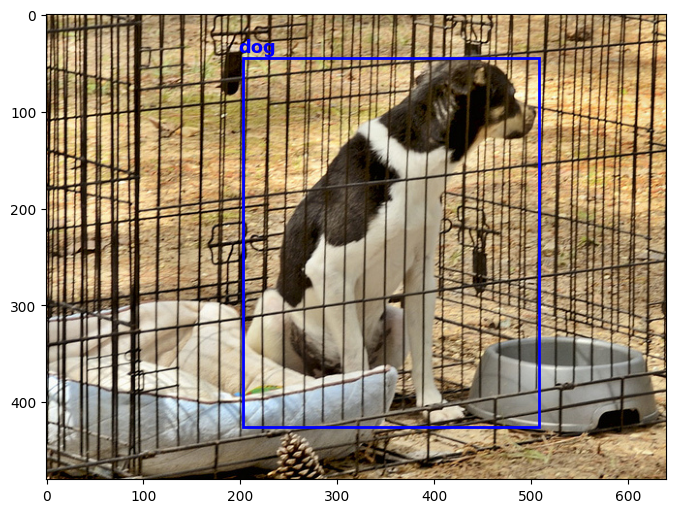

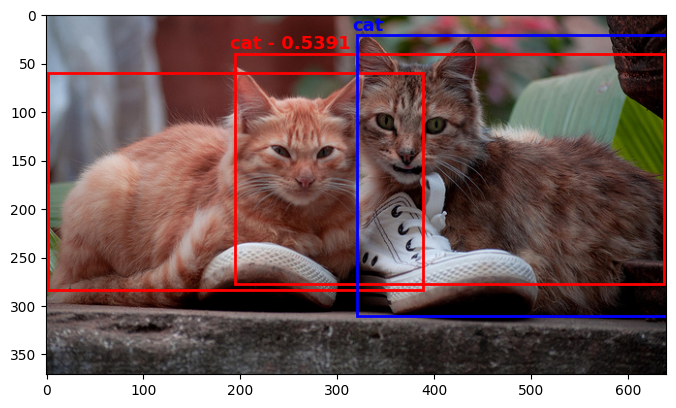

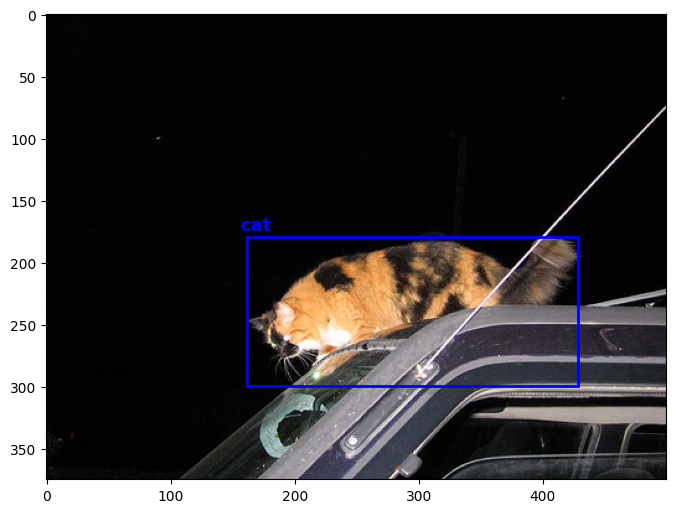

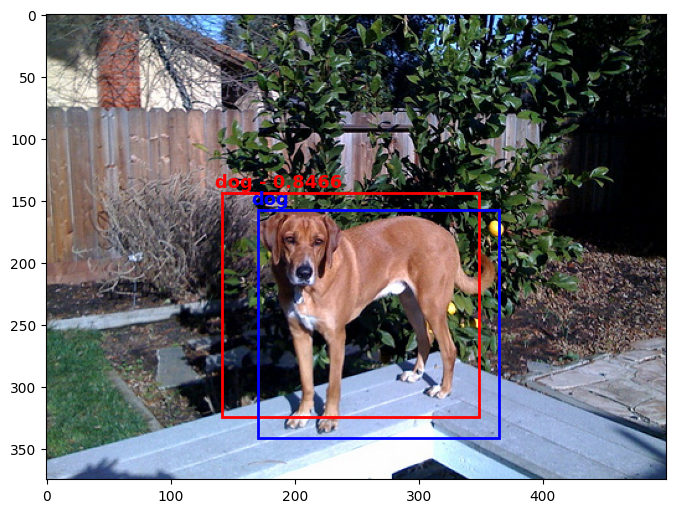

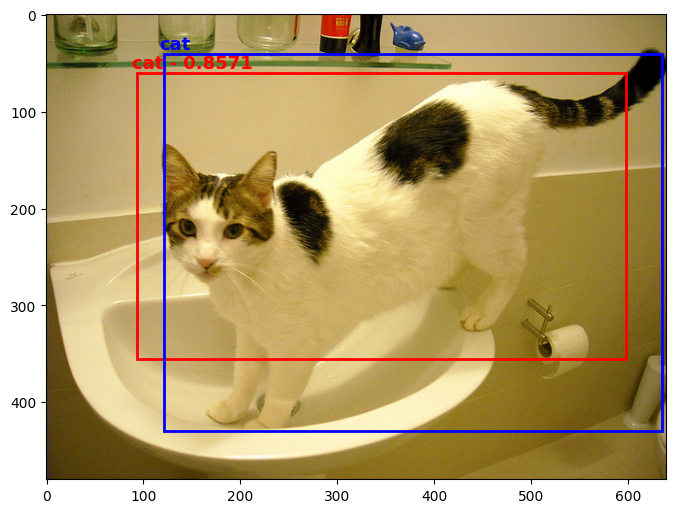

In [ ]:
### 테스트 및 시각화 관련 코드 ###

# numpy는 'Numerical Python'의 약자로, 파이썬에서 행렬, 벡터 등 다차원 배열을 매우 효율적으로 다루게 해주는 라이브러리입니다.
# PyTorch의 텐서는 GPU에서 계산이 가능하지만, Matplotlib 같은 다른 라이브러리와 데이터를 주고받으려면
# 먼저 CPU로 데이터를 옮긴 후, numpy 배열 형태로 변환하는 과정이 필요합니다.
import numpy as np
# matplotlib는 데이터를 그래프나 이미지 형태로 시각화하여 보여주는 가장 대표적인 라이브러리입니다.
# 'pyplot'은 그림을 그리고, 축을 설정하고, 색을 지정하는 등 실제 시각화 작업을 수행하는 명령어들을 모아놓은 모듈입니다.
from matplotlib import pyplot as plt
# torchvision 라이브러리에 포함된 유용한 함수로, PyTorch의 이미지 텐서([채널, 높이, 너비] 형식)를
# 사람이 눈으로 보거나 파일로 저장하기 쉬운 일반적인 이미지 형식(PIL Image)으로 되돌려줍니다.
from torchvision.transforms.functional import to_pil_image

# ----------------------------------------------------------------------------------------------------
# [보조 함수 정의: 바운딩 박스 시각화]

# 이 함수는 복잡한 시각화 로직을 'draw_bbox'라는 간단한 명령어 하나로 압축하는 역할을 합니다.
# 이렇게 하면 아래의 메인 루프 코드가 훨씬 간결해지고, "무엇을 하는지"에 더 집중할 수 있게 됩니다.
def draw_bbox(ax, box, text, color):
    # ax: 그림을 그릴 '도화지'입니다. 모든 그림 요소(사각형, 글자)는 이 도화지 위에 그려집니다.
    # box: [x_min, y_min, x_max, y_max] 형태의 좌표입니다.
    # text: 박스에 표시될 라벨입니다.
    # color: 박스와 라벨의 색상입니다.

    # 'ax.add_patch'는 도화지에 '조각(patch)' 즉, 도형을 붙이는 기능입니다.
    # 'plt.Rectangle'은 그릴 사각형의 명세(specification)를 정의합니다.
    ax.add_patch(
        plt.Rectangle(
            # xy: 사각형의 시작점 좌표를 지정합니다. Matplotlib은 도형의 '왼쪽 아래' 꼭짓점을 기준으로 합니다.
            #     하지만 이미지 좌표계(0,0이 왼쪽 위)와 잘 맞기 때문에 box의 (x_min, y_min)을 그대로 사용합니다.
            xy=(box[0], box[1]),
            # width/height: 사각형의 너비와 높이를 계산하여 지정합니다.
            width=box[2] - box[0],      # 너비 = x_max - x_min
            height=box[3] - box[1],     # 높이 = y_max - y_min
            fill=False,                 # 사각형 내부를 채우지 않도록 설정합니다.
            edgecolor=color,            # 테두리 색상을 지정합니다.
            linewidth=2,                # 테두리의 두께를 2로 설정합니다.
        )
    )
    # 'ax.annotate'는 도화지의 특정 위치에 텍스트 주석을 다는 기능입니다.
    ax.annotate(
        text=text,                      # 표시할 텍스트 내용을 전달합니다.
        # xy: 텍스트를 쓸 위치를 지정합니다. 박스의 왼쪽 위 꼭짓점에서 x축으로 5, y축으로 5만큼 이동한 위치에 텍스트를 배치하여
        #     박스 테두리 바로 위에 라벨이 예쁘게 보이도록 합니다.
        xy=(box[0] - 5, box[1] - 5),
        color=color,                    # 텍스트 색상
        weight="bold",                  # 글씨체를 굵게
        fontsize=13,                    # 글씨 크기를 13으로 설정
    )

# ----------------------------------------------------------------------------------------------------
# [테스트 및 시각화 루프]

num_vis = 0         # 시각화할 이미지 개수를 5개로 제한하기 위한 카운터입니다.
# 'threshold'는 모델의 '자신감(confidence score)'에 대한 필터입니다.
# 모델은 수많은 예측을 쏟아내지만, 그 중에는 확신이 거의 없는(예: 점수 0.01) 추측도 많습니다.
# 0.5라는 임계값을 설정함으로써, "나는 이 예측이 맞다고 50% 이상 확신한다!"고 말하는 결과만 인정하겠다는 의미입니다.
# 이 값을 높이면 더 확실한 결과만 보게 되고(오탐 감소), 낮추면 더 많은 결과를 보게 됩니다(미탐 감소).
threshold = 0.5
categories = test_dataset.categories # {1: 'cat', 2: 'dog', ...} 와 같이 ID와 클래스 이름이 매핑된 딕셔너리를 가져옵니다.

# 'torch.no_grad()'는 "지금부터는 학습이 아니니, 기울기(gradient)를 계산할 필요 없어!"라고 PyTorch에 알려주는 신호입니다.
# 비유: 건축가가 설계도를 검토만 할 때는(예측), 연필과 지우개(기울기 계산)를 들 필요 없이 눈으로만 보는 것과 같습니다.
# 이 블록 안의 모든 연산은 기울기 추적을 하지 않으므로, 메모리 사용량이 줄고 계산 속도가 대폭 향상됩니다.
with torch.no_grad():
    # 'model.eval()'은 모델을 '평가 모드'로 전환합니다.
    # 이는 Dropout 같은 일부 레이어의 동작을 멈춰서, 매번 실행할 때마다 예측 결과가 동일하게 나오도록 보장합니다.
    # 평가 시에는 반드시 호출해야 하는 중요한 명령어입니다.
    model.eval()
    for images, targets in test_dataloader:
        images = [image.to(device) for image in images]
        # 모델에 이미지만 넣어서 '순전파(forward pass)'를 실행합니다.
        # 평가 모드이므로 모델은 정답(targets) 없이, 스스로의 지식만으로 예측 결과를 만들어냅니다.
        outputs = model(images)

        # [결과 후처리: 모델의 언어(GPU 텐서) -> 사람의 언어(CPU Numpy 배열)]
        # 모델의 출력값은 계산이 빠른 GPU 메모리 위에 텐서 형태로 존재합니다.
        # 이를 Matplotlib이나 Numpy 같은 다른 라이브러리에서 사용하려면, 먼저 CPU 메모리로 가져온 후 Numpy 배열로 변환해야 합니다.
        boxes = outputs[0]["boxes"].to("cpu").numpy()
        labels = outputs[0]["labels"].to("cpu").numpy()
        scores = outputs[0]["scores"].to("cpu").numpy()

        # [결과 필터링: 신뢰도 높은 예측만 남기기]
        # Numpy의 강력한 '불리언 인덱싱(boolean indexing)' 기능입니다.
        # 1. 'scores >= threshold' : 모든 점수에 대해 "0.5 이상인가?"를 물어보고, [True, False, True, True, ...] 와 같은
        #                            '참/거짓 마스크'를 생성합니다.
        # 2. 'boxes[마스크]' : boxes 배열에서 이 마스크가 'True'인 행들만 골라냅니다.
        # .astype(np.int32)는 박스 좌표를 그림 그리기에 편한 정수형으로 변환합니다.
        boxes = boxes[scores >= threshold].astype(np.int32)
        # 동일한 마스크를 사용해 라벨과 점수도 필터링합니다. 이제 boxes, labels, scores는 모두 같은 개수의 요소를 가집니다.
        labels = labels[scores >= threshold]
        scores = scores[scores >= threshold]

        # [시각화: 예측과 정답을 한눈에 비교하기]
        fig = plt.figure(figsize=(8, 8)) # 가로세로 8인치의 그림판(figure) 생성
        ax = fig.add_subplot(1, 1, 1)    # 그림판을 1x1로 나누고 첫 번째 칸에 도화지(axes) 생성
        # 이미지 텐서를 다시 사람이 볼 수 있는 PIL 이미지로 변환하여 도화지에 표시합니다.
        plt.imshow(to_pil_image(images[0]))

        # 'zip' 함수는 여러 리스트의 요소들을 같은 순서끼리 묶어줍니다.
        # 필터링된 예측 결과(박스, 라벨, 점수)를 하나씩 꺼내면서 반복합니다.
        for box, label, score in zip(boxes, labels, scores):
            # 'draw_bbox' 함수를 호출하여 '빨간색'으로 예측 결과를 그립니다.
            # 라벨에는 클래스 이름과 신뢰도 점수를 함께 표시하여, 모델이 '무엇'을 '얼마나 확신'하는지 보여줍니다.
            draw_bbox(ax, box, f"{categories[label]} - {score:.4f}", "red")

        # 이번에는 '정답(Ground Truth)' 데이터들을 순회하며, '파란색'으로 정답 박스를 그립니다.
        tboxes = targets[0]["boxes"].numpy()
        tlabels = targets[0]["labels"].numpy()
        for box, label in zip(tboxes, tlabels):
            draw_bbox(ax, box, f"{categories[label]}", "blue")

        # '빨간색(예측)'과 '파란색(정답)'을 비교하면 모델의 성능을 직관적으로 파악할 수 있습니다.
        # - 빨간색과 파란색이 거의 겹치면: 성공적인 예측 (True Positive)
        # - 파란색만 있으면: 모델이 놓친 객체 (False Negative)
        # - 빨간색만 있으면: 모델이 잘못 예측한 객체 (False Positive)
        plt.show()

        num_vis += 1
        # 5개의 이미지를 시각화했으면 더 이상 진행하지 않고 루프를 빠져나갑니다.
        if num_vis == 5:
            break

In [ ]:
### IoU 및 mAP 평가 관련 함수 ###

# 이 함수는 모델 성능 평가의 가장 기본이 되는 '유사도'를 계산합니다.
# 예측 박스와 정답 박스가 얼마나 겹치는지를 0과 1 사이의 숫자로 표현하며,
# 이 값이 높을수록 모델이 객체의 위치를 정확하게 예측했음을 의미합니다.
def compute_iou_numpy(boxes1, boxes2):
    # IoU(Intersection over Union) = (교집합 영역 넓이) / (합집합 영역 넓이)
    # boxes1: 예측 박스들의 배열 (N개의 박스)
    # boxes2: 정답 박스들의 배열 (M개의 박스)
    # 이 함수의 최종 결과는 (N, M) 크기의 행렬이며, 각 요소 (i, j)는
    # 예측 박스 i와 정답 박스 j 사이의 IoU 값을 의미합니다.

    # [1단계: 각 박스의 넓이 계산]
    # area = width * height = (x_max - x_min) * (y_max - y_min)
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    # [2단계: 교집합(Intersection) 영역의 좌표 계산]
    # 이 부분은 Numpy의 '브로드캐스팅(broadcasting)' 기능을 활용하여
    # 모든 예측 박스와 모든 정답 박스 간의 비교를 한 번의 연산으로 수행합니다.
    # inter_x1: 교집합의 왼쪽 위 x좌표. 두 박스의 왼쪽 위 x좌표 중 더 '큰' 값 (더 오른쪽에 있는 값)
    inter_x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    # inter_y1: 교집합의 왼쪽 위 y좌표. 두 박스의 왼쪽 위 y좌표 중 더 '큰' 값 (더 아래쪽에 있는 값)
    inter_y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    # inter_x2: 교집합의 오른쪽 아래 x좌표. 두 박스의 오른쪽 아래 x좌표 중 더 '작은' 값 (더 왼쪽에 있는 값)
    inter_x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    # inter_y2: 교집합의 오른쪽 아래 y좌표. 두 박스의 오른쪽 아래 y좌표 중 더 '작은' 값 (더 위쪽에 있는 값)
    inter_y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])

    # [3단계: 교집합 넓이와 합집합 넓이 계산]
    # 교집합의 너비(width)와 높이(height)를 계산합니다.
    # 'np.maximum(..., 0)'은 박스들이 아예 겹치지 않아 너비나 높이가 음수가 될 경우, 0으로 처리해줍니다.
    inter_w = np.maximum(inter_x2 - inter_x1, 0)
    inter_h = np.maximum(inter_y2 - inter_y1, 0)
    inter_area = inter_w * inter_h # 교집합 넓이
    # 합집합 넓이 = (박스1 넓이) + (박스2 넓이) - (교집합 넓이)
    union_area = area1[:, None] + area2 - inter_area
    # 1e-6은 0으로 나누는 것을 방지하기 위한 아주 작은 값입니다.
    return inter_area / (union_area + 1e-6)

# 이 함수는 한 클래스(예: '고양이')에 대한 모델의 성능을 종합적인 점수 하나로 요약합니다.
# Precision-Recall Curve 아래쪽의 면적을 계산하여 AP(Average Precision)를 구합니다.
def voc_ap(recalls, precisions):
    # recalls: 재현율(Recall) 값들의 배열. 모델이 실제 정답들 중 얼마나 많이 찾아냈는지를 나타냅니다.
    # precisions: 정밀도(Precision) 값들의 배열. 모델이 '정답'이라고 예측한 것들 중 실제 정답의 비율입니다.

    # [1단계: P-R Curve의 시작점과 끝점 추가]
    # 계산의 편의를 위해, 재현율의 시작은 0, 끝은 1로 설정하고, 정밀도도 양 끝에 0을 추가합니다.
    mrec = np.concatenate(([0.], recalls, [1.]))
    mpre = np.concatenate(([0.], precisions, [0.]))

    # [2단계: 정밀도 값 보정 (Smoothing)]
    # PASCAL VOC 평가 방식의 핵심입니다. P-R Curve가 울퉁불퉁하게 그려지는 것을 막기 위해,
    # 특정 재현율 지점에서의 정밀도를 '그 지점보다 높은 재현율에서 달성했던 가장 높은 정밀도 값'으로 보정합니다.
    # 이렇게 하면 그래프가 계단처럼 단조롭게 감소하는 모양이 됩니다.
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # [3단계: AP 계산]
    # 재현율 값이 실제로 변하는 지점들('계단의 수직선 부분')을 찾습니다.
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    # 각 계단 모양 사각형의 넓이(가로 길이 * 세로 높이)를 모두 더합니다.
    # 가로 길이 = 재현율의 변화량 (mrec[idx + 1] - mrec[idx])
    # 세로 높이 = 보정된 정밀도 값 (mpre[idx + 1])
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return ap

# 이 함수는 전체 평가 과정을 총괄하는 메인 컨트롤러입니다.
# 모든 예측과 정답 데이터를 받아서, 각 클래스별 AP를 계산하고, 이들의 평균인 mAP를 최종 결과로 도출합니다.
def evaluate_detections(predictions, ground_truths, iou_threshold=0.5, num_classes=3):
    aps = [] # 각 클래스별 AP 점수를 저장할 리스트

    # 배경 클래스(0)를 제외한 나머지 클래스에 대해 순서대로 평가를 진행합니다.
    for cls in range(1, num_classes):
        # [1단계: 데이터 준비]
        # 전체 예측 결과('predictions') 중에서 현재 평가하려는 클래스('cls')에 해당하는 것만 골라냅니다.
        cls_preds = [p for p in predictions if p["label"] == cls]
        # 모델이 얼마나 확신하는지를 나타내는 'score'를 기준으로 내림차순 정렬합니다.
        # 가장 자신 있는 예측부터 평가를 시작해야 하기 때문입니다.
        cls_preds = sorted(cls_preds, key=lambda p: p["score"], reverse=True)

        # 전체 정답 데이터('ground_truths')를 이미지 ID별로 정리하여 쉽게 찾아쓸 수 있도록 딕셔너리로 만듭니다.
        # "detected"는 각 정답 박스가 이미 예측과 매칭되었는지 추적하는 '체크리스트'입니다. (하나의 정답에 여러 예측이 매칭되는 것을 방지)
        gt_by_image = {}
        for gt in ground_truths:
            inds = np.where(gt["labels"] == cls)[0]
            boxes = gt["boxes"][inds] if len(inds) > 0 else np.array([]).reshape(0, 4)
            gt_by_image[gt["image_id"]] = {"boxes": boxes, "detected": np.zeros(len(boxes), dtype=bool)}

        # 현재 클래스의 전체 정답(Ground Truth) 개수를 셉니다. (Recall 계산 시 분모로 사용)
        num_gt = sum([len(v["boxes"]) for v in gt_by_image.values()])
        if num_gt == 0: continue # 정답이 하나도 없으면 평가할 수 없으므로 다음 클래스로 넘어갑니다.

        # [2단계: 예측과 정답 매칭 (TP/FP 판정)]
        # 각 예측이 True Positive(정답)인지 False Positive(오답)인지를 기록할 배열을 생성합니다.
        tp = np.zeros(len(cls_preds))
        fp = np.zeros(len(cls_preds))

        # 가장 자신 있는 예측부터 하나씩 순회합니다.
        for i, pred in enumerate(cls_preds):
            image_id = pred["image_id"]
            pred_box_xyxy = np.array([pred["bbox"][0], pred["bbox"][1], pred["bbox"][0] + pred["bbox"][2], pred["bbox"][1] + pred["bbox"][3]])

            if image_id in gt_by_image:
                gt_boxes = gt_by_image[image_id]["boxes"]
                if gt_boxes.shape[0] == 0: # 해당 이미지에 정답이 없는데 예측을 한 경우 -> 오답(FP)
                    fp[i] = 1
                else:
                    # 현재 예측 박스와 해당 이미지의 모든 정답 박스들 간의 IoU를 계산합니다.
                    ious = compute_iou_numpy(np.expand_dims(pred_box_xyxy, axis=0), gt_boxes)
                    max_iou = np.max(ious) if ious.size > 0 else 0
                    max_ind = np.argmax(ious) if ious.size > 0 else -1

                    # 가장 높게 겹치는 정답 박스와의 IoU가 임계값(0.5) 이상이면,
                    if max_iou >= iou_threshold:
                        # 그리고 그 정답 박스가 아직 다른 예측과 매칭된 적이 없다면,
                        if not gt_by_image[image_id]["detected"][max_ind]:
                            # 이 예측은 '정답(TP)'입니다.
                            tp[i] = 1
                            # 이 정답 박스는 이제 '매칭됨'으로 체크리스트에 표시합니다.
                            gt_by_image[image_id]["detected"][max_ind] = True
                        else: # IoU는 높지만, 이미 다른 (더 자신 있는) 예측이 가져간 정답이라면 -> 오답(FP)
                            fp[i] = 1
                    else: # IoU가 임계값보다 낮다면 -> 오답(FP)
                        fp[i] = 1
            else: # 예측한 이미지가 정답 데이터에 아예 존재하지 않는 경우 -> 오답(FP)
                fp[i] = 1

        # [3단계: Precision, Recall, AP 계산]
        # TP와 FP의 누적 합계를 계산하여, 각 예측 지점에서의 Precision과 Recall을 구합니다.
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recalls = cum_tp / (num_gt + 1e-6)
        precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

        # 계산된 P-R 값들을 바탕으로 현재 클래스의 AP 점수를 최종 계산합니다.
        ap = voc_ap(recalls, precisions)
        print(f"클래스 {cls} AP: {ap:.3f}")
        aps.append(ap)

    # [4단계: mAP 계산]
    # 모든 클래스에 대한 AP 점수들의 평균(mean)을 계산하여 최종 성능 지표인 mAP를 구합니다.
    mAP = np.mean(aps) if aps else 0.0
    print(f"전체 mAP: {mAP:.3f}")
    return mAP

In [ ]:
### Ground Truth와 예측 결과 준비 ###

# [1단계: Ground Truth(정답) 데이터 포맷팅]
# 목표: 우리 `test_dataset`에 들어있는 정답 데이터를 `evaluate_detections` 함수가 요구하는 형식(딕셔너리의 리스트)으로 변환합니다.

# 최종 결과를 담을 빈 리스트를 생성합니다.
ground_truths = []
# `test_dataset.data`는 `(이미지, 정답)` 튜플들이 담긴 리스트입니다.
# `_`는 이미지 데이터는 사용하지 않을 것이라는 의미의 관례적인 표현입니다. 우리는 정답(`target`)만 필요합니다.
for _, target in test_dataset.data:
    # 각 이미지의 정답 정보를 담을 새로운 딕셔너리('gt')를 생성합니다.
    gt = {
        # `target["image_id"]`는 `tensor([123])`과 같은 텐서이므로,
        # `.item()`으로 숫자 값만 추출하고, `int()`로 파이썬 정수형으로 변환합니다.
        "image_id": int(target["image_id"].item()),
        # 정답 박스 좌표 텐서를 numpy 배열로 변환합니다. 형식은 [x_min, y_min, x_max, y_max]입니다.
        "boxes": target["boxes"].numpy(),
        # 정답 라벨 텐서를 numpy 배열로 변환합니다.
        "labels": target["labels"].numpy()
    }
    # 완성된 딕셔너리를 `ground_truths` 리스트에 추가합니다.
    ground_truths.append(gt)

# [2단계: 모델 예측(Prediction) 결과 생성 및 포맷팅]
# 목표: 테스트 데이터셋 전체에 대해 모델을 실행하여 모든 예측 결과를 얻고,
#       이 결과들을 `evaluate_detections` 함수가 요구하는 형식으로 변환합니다.
#       (각 예측 박스 하나하나가 개별 딕셔너리가 되는 '평평한' 리스트)

# 모든 예측 결과를 담을 빈 리스트를 생성합니다.
predictions = []
# 기울기 계산을 비활성화하여 메모리와 속도를 최적화합니다.
with torch.no_grad():
    # 모델을 평가 모드로 설정합니다.
    model.eval()
    # 테스트 데이터 로더에서 배치 단위로 데이터를 꺼냅니다.
    for images, targets in test_dataloader:
        images = [img.to(device) for img in images]
        # 모델에 이미지를 입력하여 예측 결과를 얻습니다.
        outputs = model(images)
        # 배치에 포함된 각 이미지에 대한 결과를 하나씩 처리합니다.
        for i in range(len(targets)):
            # `targets`에서 현재 이미지의 ID를 가져와 예측 결과와 연결합니다.
            image_id = int(targets[i]["image_id"].item())

            # 예측 결과를 GPU에서 CPU로 옮기고 numpy 배열로 변환합니다.
            boxes = outputs[i]["boxes"].data.cpu().numpy()
            scores = outputs[i]["scores"].data.cpu().numpy()
            labels = outputs[i]["labels"].data.cpu().numpy()

            # 한 이미지에 대해 모델이 예측한 여러 개의 박스들을 하나씩 순회합니다.
            for j in range(len(boxes)):
                # j번째 예측 박스의 좌표를 가져옵니다.
                box = boxes[j]
                # 평가 함수는 `[x, y, w, h]` 형식을 요구하므로, 모델 출력 형식인 `[x_min, y_min, x_max, y_max]`를 변환합니다.
                # w = x_max - x_min, h = y_max - y_min
                bbox = [box[0], box[1], box[2] - box[0], box[3] - box[1]]
                # 이 '단일 예측'에 대한 모든 정보를 담은 딕셔너리를 생성하여
                # `predictions` 리스트에 추가합니다.
                predictions.append({
                    "image_id": image_id,
                    "bbox": bbox,
                    "score": float(scores[j]),
                    "label": int(labels[j])
                })

# [3단계: 최종 평가 실행]
# 위에서 정성껏 준비한 두 데이터(predictions, ground_truths)를 평가 함수에 전달하여
# 모델의 최종 성능 점수(mAP)를 계산하고 출력합니다.
evaluate_detections(
    predictions=predictions,        # 모델이 예측한 모든 결과물
    ground_truths=ground_truths,    # 데이터셋의 모든 정답
    iou_threshold=0.5,              # IoU가 0.5 이상일 때 '맞았다(TP)'고 판정
    num_classes=3                   # 전체 클래스 수 (배경 포함)
)

클래스 1 AP: 0.641
클래스 2 AP: 0.604
전체 mAP: 0.623


np.float64(0.6226361780052165)

### 모델링(Pycocotools 활용)

- MS COCO 데이터 측에서 제공하는 관련 툴 : https://github.com/cocodataset/cocoapi/tree/master/PythonAPI

In [ ]:
# # 먼저, 압축 파일(pytorch-transformer.zip)을 지정된 경로(현재 디렉토리)로 압축 해제합니다.
# import shutil
# shutil.unpack_archive(
#     filename="pytorch-transformer.zip",  # 압축 해제할 파일 경로
#     extract_dir="./",                     # 압축 해제할 디렉토리 (현재 디렉토리)
#     format="zip"                          # 압축 파일 형식 지정
# )

In [ ]:
# 작업 디렉토리를 변경합니다.
import os
os.chdir("/content/4/datasets/")  # 작업할 데이터셋 폴더로 이동 (실행 환경에 따라 경로가 달라질 수 있음)

In [ ]:
# 필요한 라이브러리들을 임포트합니다.
import torch
from PIL import Image                   # 이미지 처리를 위한 Pillow 라이브러리
from pycocotools.coco import COCO         # COCO 데이터셋을 다루기 위한 라이브러리
from torch.utils.data import Dataset      # PyTorch의 Dataset 클래스를 상속받기 위해 사용


# COCO 데이터셋을 처리하기 위한 사용자 정의 Dataset 클래스
class COCODataset(Dataset):
    def __init__(self, root, train, transform=None):
        """
        초기화 함수:
        - root: 데이터셋의 최상위 경로
        - train: 학습용 데이터(True)와 검증용 데이터(False) 구분
        - transform: 이미지 전처리를 위한 변환 함수 (예: tensor 변환)
        """
        super().__init__()
        # 'train'이 True면 'train' 디렉토리, 아니면 'val' 디렉토리를 사용합니다.
        directory = "train" if train else "val"
        # 해당 디렉토리의 주석(annotation) 파일 경로를 설정합니다.
        annotations = os.path.join(root, "annotations", f"{directory}_annotations.json")

        # COCO 형식의 주석 데이터를 불러옵니다.
        self.coco = COCO(annotations)
        # 이미지가 저장된 경로 설정 (train 또는 val 디렉토리)
        self.image_path = os.path.join(root, directory)
        # 이미지 전처리 변환 함수 저장
        self.transform = transform

        # 데이터셋 내 모든 카테고리 정보를 가져옵니다.
        self.categories = self._get_categories()
        # 이미지와 그에 해당하는 어노테이션을 로드합니다.
        self.data = self._load_data()

    def _get_categories(self):
        """
        COCO 데이터셋 내 카테고리 정보를 딕셔너리 형태로 반환합니다.
        0번 인덱스는 배경("background")으로 초기화합니다.
        """
        categories = {0: "background"}
        for category in self.coco.cats.values():
            categories[category["id"]] = category["name"]
        return categories

    def _load_data(self):
        """
        COCO 데이터셋의 각 이미지에 대해:
        - 이미지를 로드하고,
        - 해당 이미지의 어노테이션(바운딩 박스와 라벨)을 추출하여 target으로 구성합니다.
        그리고 (이미지, target) 튜플의 리스트로 반환합니다.
        """
        data = []
        for _id in self.coco.imgs:
            # 이미지 정보를 불러오고 파일 이름을 추출합니다.
            file_name = self.coco.loadImgs(_id)[0]["file_name"]
            # 파일 경로 생성
            image_path = os.path.join(self.image_path, file_name)
            # 이미지를 RGB 모드로 열기
            image = Image.open(image_path).convert("RGB")

            boxes = []   # 바운딩 박스 좌표를 저장할 리스트
            labels = []  # 해당 박스의 카테고리 id 저장할 리스트
            # 이미지에 해당하는 모든 어노테이션 정보를 불러옵니다.
            anns = self.coco.loadAnns(self.coco.getAnnIds(_id))
            for ann in anns:
                # 어노테이션에서 x, y 좌표와 width, height를 가져옵니다.
                x, y, w, h = ann["bbox"]
                # 좌표 정보를 [x_min, y_min, x_max, y_max] 형태로 변환하여 저장
                #  (Faster RCNN은 x_min, y_min, x_max, y_max 형태 사용)
                boxes.append([x, y, x + w, y + h])
                # 라벨 정보(카테고리 id)를 저장
                labels.append(ann["category_id"])

            # target 딕셔너리에 이미지 id, 바운딩 박스, 라벨 정보를 tensor로 변환하여 저장
            target = {
                "image_id": torch.LongTensor([_id]),
                "boxes": torch.FloatTensor(boxes),
                "labels": torch.LongTensor(labels)
            }
            # 이미지와 target 정보를 튜플 형태로 저장
            data.append([image, target])
        return data

    def __getitem__(self, index):
        """
        Dataset의 특정 index에 해당하는 (이미지, target) 튜플을 반환합니다.
        만약 transform이 있다면 이미지에 적용합니다.
        """
        image, target = self.data[index]
        if self.transform:
            image = self.transform(image)
        return image, target

    def __len__(self):
        """
        데이터셋의 전체 샘플 개수를 반환합니다.
        """
        return len(self.data)

In [ ]:
# torchvision 라이브러리에서 이미지 전처리 도구와 DataLoader를 임포트합니다.
from torchvision import transforms
from torch.utils.data import DataLoader

# 배치 데이터를 생성할 때, 각 배치마다 데이터를 튜플 형태로 묶어주는 함수
# coco 데이터 셋은 이미지 내에 여러 객체 정보가 담길 수 있으므로, 데이터의 길이가 다를 수 있음.
def collator(batch):
    return tuple(zip(*batch))

# 이미지 전처리: PIL 이미지를 텐서로 변환하고, 데이터 타입을 float으로 변환
transform = transforms.Compose(
    [
        transforms.PILToTensor(),
        transforms.ConvertImageDtype(dtype=torch.float)
    ]
)

# 학습 데이터와 테스트(검증) 데이터를 위한 COCO 데이터셋 객체 생성
train_dataset = COCODataset("./coco", train=True, transform=transform)
test_dataset = COCODataset("./coco", train=False, transform=transform)

# DataLoader를 사용하여 데이터셋을 배치 단위로 불러옵니다.
train_dataloader = DataLoader(
    train_dataset, batch_size=4, shuffle=True, drop_last=True, collate_fn=collator
)
test_dataloader = DataLoader(
    test_dataset, batch_size=1, shuffle=True, drop_last=True, collate_fn=collator
)

In [ ]:
# torchvision 라이브러리에서 사전 학습된 모델과 관련 모듈을 임포트합니다.
from torchvision import models
from torchvision import ops
from torchvision.models.detection import rpn
from torchvision.models.detection import FasterRCNN

# 사전 학습된 VGG16 모델의 feature extractor(특징 추출기)를 backbone으로 사용합니다.
backbone = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features
backbone.out_channels = 512  # backbone의 출력 채널 수 설정

# RPN(Region Proposal Network)에서 사용할 앵커 생성기 설정
anchor_generator = rpn.AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),       # 각 스케일별 앵커 크기 지정
    aspect_ratios=((0.5, 1.0, 2.0),)         # 각 앵커의 가로 세로 비율 지정
)

# ROI Pooling: 여러 스케일의 특징맵에서 RoI(Region of Interest)를 고정 크기로 변환
roi_pooler = ops.MultiScaleRoIAlign(
    featmap_names=["0"],         # 사용할 특징맵 이름
    output_size=(7, 7),          # 출력 크기 설정 (7x7)
    sampling_ratio=2             # 샘플링 비율 지정
)

# 학습에 사용할 디바이스를 설정 (GPU가 있으면 cuda, 없으면 cpu)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Faster R-CNN 모델을 생성합니다.
# - backbone: 특징 추출기 (VGG16 사용)
# - num_classes: 검출할 클래스 수 (배경 포함; 여기서는 3개로 설정)
# - rpn_anchor_generator: 위에서 설정한 앵커 생성기
# - box_roi_pool: 위에서 설정한 ROI 풀링 모듈
model = FasterRCNN(
    backbone=backbone,
    num_classes=3,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
).to(device)  # 모델을 선택한 디바이스로 이동


In [ ]:
# 모델 학습을 위한 최적화 기법 설정 (SGD 사용)
from torch import optim
params = [p for p in model.parameters() if p.requires_grad]  # 학습 가능한 파라미터들만 선택
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
# 학습률 스케줄러: 일정 에폭마다 학습률 감소
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
from tqdm import tqdm

# 학습 루프 (5 에폭 동안 학습)
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    # tqdm 진행바를 사용하여 학습 진행 표시
    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")
    for images, targets in train_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        train_bar.set_postfix(loss=f"{losses.item():.3f}")

    lr_scheduler.step()
    avg_train_loss = total_loss / len(train_dataloader)


    print(f"Epoch: {epoch+1:2d}, Avg Train Loss: {avg_train_loss:.3f}")

    # 사용하지 않는 GPU 메모리 해제
    torch.cuda.empty_cache()


In [ ]:
# 테스트 이미지에 대한 예측 결과를 시각화하기 위한 라이브러리 임포트
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms.functional import to_pil_image

# 바운딩 박스를 그림으로 표시하는 함수 정의
def draw_bbox(ax, box, text, color):
    """
    - ax: matplotlib Axes 객체
    - box: 바운딩 박스 좌표 (x_min, y_min, x_max, y_max)
    - text: 바운딩 박스 위에 표시할 텍스트
    - color: 바운딩 박스와 텍스트의 색상
    """
    ax.add_patch(
        plt.Rectangle(
            xy=(box[0], box[1]),
            width=box[2] - box[0],
            height=box[3] - box[1],
            fill=False,
            edgecolor=color,
            linewidth=2,
        )
    )
    ax.annotate(
        text=text,
        xy=(box[0] - 5, box[1] - 5),
        color=color,
        weight="bold",
        fontsize=13,
    )

# 임계값(threshold) 설정: 예측 점수가 이 값 이상일 때만 결과를 사용
threshold = 0.5
categories = test_dataset.categories  # 테스트 데이터셋의 카테고리 정보를 사용
with torch.no_grad():  # 평가 시에는 기울기 계산을 하지 않음
    model.eval()       # 모델을 평가 모드로 전환
    # 테스트 데이터셋의 배치 단위로 반복
    for images, targets in test_dataloader:
        # 이미지를 디바이스로 이동
        images = [image.to(device) for image in images]
        # 모델을 통해 예측 수행
        outputs = model(images)

        # 예측 결과에서 바운딩 박스, 라벨, 점수를 CPU의 numpy 배열로 변환
        boxes = outputs[0]["boxes"].to("cpu").numpy()
        labels = outputs[0]["labels"].to("cpu").numpy()
        scores = outputs[0]["scores"].to("cpu").numpy()

        # 점수가 threshold 이상인 예측만 선택
        boxes = boxes[scores >= threshold].astype(np.int32)
        labels = labels[scores >= threshold]
        scores = scores[scores >= threshold]

        # 시각화를 위한 플롯 설정 (그림 크기 8x8)
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        plt.imshow(to_pil_image(images[0]))  # 첫 번째 이미지를 PIL 이미지로 변환 후 출력

        # 예측 결과(빨간색 박스) 시각화
        for box, label, score in zip(boxes, labels, scores):
            draw_bbox(ax, box, f"{categories[label]} - {score:.4f}", "red")

        # 정답 어노테이션(파란색 박스) 시각화
        tboxes = targets[0]["boxes"].numpy()
        tlabels = targets[0]["labels"].numpy()
        for box, label in zip(tboxes, tlabels):
            draw_bbox(ax, box, f"{categories[label]}", "blue")

        plt.show()  # 시각화 결과 출력

In [ ]:
# COCO 평가 도구를 사용하여 모델의 성능을 평가합니다.
import numpy as np
from pycocotools.cocoeval import COCOeval

with torch.no_grad():
    model.eval()
    coco_detections = []  # COCO 형식의 예측 결과를 저장할 리스트
    # 테스트 데이터셋 배치 단위 반복
    for images, targets in test_dataloader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i in range(len(targets)):
            # 이미지 id 추출 (COCO 형식은 이미지 id가 필요)
            image_id = targets[i]["image_id"].data.cpu().numpy().tolist()[0]
            # 예측한 바운딩 박스 추출 (좌표 값)
            boxes = outputs[i]["boxes"].data.cpu().numpy()
            # COCO 평가 형식에 맞게 [x, y, width, height] 형태로 변환
            boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
            boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
            scores = outputs[i]["scores"].data.cpu().numpy()
            labels = outputs[i]["labels"].data.cpu().numpy()

            # 각 예측 인스턴스에 대해 COCO 평가용 배열 생성
            for instance_id in range(len(boxes)):
                box = boxes[instance_id, :].tolist()
                prediction = np.array(
                    [
                        image_id,                # 이미지 id
                        box[0],                  # x 좌표
                        box[1],                  # y 좌표
                        box[2],                  # width (x_max - x_min)
                        box[3],                  # height (y_max - y_min)
                        float(scores[instance_id]),  # 예측 점수
                        int(labels[instance_id]),      # 예측 라벨
                    ]
                )
                coco_detections.append(prediction)

    coco_detections = np.asarray(coco_detections)  # 리스트를 numpy 배열로 변환
    coco_gt = test_dataloader.dataset.coco        # COCO 형식의 ground truth 어노테이션 로드
    coco_dt = coco_gt.loadRes(coco_detections)      # 예측 결과를 COCO 형식으로 변환
    coco_evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")  # 평가 도구 초기화 (bbox 기준)
    coco_evaluator.evaluate()   # 각 이미지별 평가 수행
    coco_evaluator.accumulate() # 결과 누적
    coco_evaluator.summarize()  # 평가 결과 요약 및 출력


# 실습(Pascal VOC 2007)

In [ ]:
# VOC2007 train/val 데이터셋 다운로드 (예: VOCtrainval_06-Nov-2007.tar)
!wget http://pjreddie.com/media/files/VOCtrainval_06-Nov-2007.tar

# 압축 해제 (VOCdevkit/VOC2007 폴더가 생성됨)
!tar -xvf VOCtrainval_06-Nov-2007.tar

In [ ]:
import os
import xml.etree.ElementTree as ET
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models, ops
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import rpn
from torch import optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm

# VOC 클래스 목록 (첫번째 __background__ 포함)
VOC_CLASSES = (
    "__background__",
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
)
# 클래스 이름을 id로 매핑하는 딕셔너리 생성 (ex: 'cat': 9)
VOC_CLASS_TO_ID = {cls: idx for idx, cls in enumerate(VOC_CLASSES)}

class VOCDataset(Dataset):
    def __init__(self, root, image_set="train", transform=None):
        """
        Args:
            root (str): VOC 데이터셋의 루트 경로 (예: "VOCdevkit/VOC2007")
            image_set (str): 사용할 이미지 세트("train", "val" 또는 "test")
            transform: 이미지 전처리(transform)를 위한 torchvision.transforms 객체
        """
        self.root = root
        self.image_set = image_set
        self.transform = transform

        # VOC 데이터셋은 보통 ImageSets/Main 폴더에 train.txt, val.txt 등이 있음.
        # 해당 파일이 존재하면 그 파일의 id 목록을 사용하고, 없으면 JPEGImages 폴더의 모든 파일을 사용합니다.
        imageset_file = os.path.join(root, "ImageSets", "Main", f"{image_set}.txt")
        if os.path.exists(imageset_file):
            with open(imageset_file, "r") as f:
                self.ids = [line.strip() for line in f.readlines()]
        else:
            # 파일명이 확장자를 제외한 이름으로 id로 사용
            jpeg_folder = os.path.join(root, "JPEGImages")
            self.ids = [os.path.splitext(f)[0] for f in os.listdir(jpeg_folder) if f.endswith(".jpg")]

        self.jpeg_folder = os.path.join(root, "JPEGImages")
        self.ann_folder = os.path.join(root, "Annotations")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        """
        이미지와 해당 어노테이션(target)을 반환합니다.
        target은 다음의 key를 포함하는 딕셔너리입니다.
            - image_id: 이미지 id (tensor)
            - boxes: 바운딩 박스 좌표 [xmin, ymin, xmax, ymax] (FloatTensor)
            - labels: 클래스 id (LongTensor)
        """
        img_id = self.ids[index]
        # 이미지 파일 경로
        img_path = os.path.join(self.jpeg_folder, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        # 어노테이션 XML 파일 경로
        ann_path = os.path.join(self.ann_folder, f"{img_id}.xml")
        boxes = []
        labels = []

        # XML 파싱
        tree = ET.parse(ann_path)
        root_xml = tree.getroot()
        # VOC XML 형식에서 object 태그 아래 정보를 읽음
        for obj in root_xml.findall("object"):
            # difficult 속성이 있으면 고려할 수 있음 (여기서는 모두 사용)
            # difficult = int(obj.find("difficult").text)
            name = obj.find("name").text.lower().strip()
            # VOC 클래스 목록에 없는 클래스라면 건너뜀
            if name not in VOC_CLASS_TO_ID:
                continue
            label = VOC_CLASS_TO_ID[name]
            bndbox = obj.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        # target 딕셔너리 구성 (이미지 id는 index 사용)
        target = {
            "image_id": torch.tensor([index]),
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        if self.transform:
            image = self.transform(image)

        return image, target
